# PhysCLIP Benchmark Suite (Clean)

This notebook provides a **single, consistent benchmark pipeline** for **three baselines**:

- **CLIP (OpenAI / open\_clip)**  
- **AstroCLIP** (image–spectrum aligned; **no natural-language text encoder**)  
- **PhysCLIP** (your CLIP-style astro model)

## Tasks

| Task | Dataset | Metric(s) | Notes |
|---|---|---|---|
| Image classification | SpaceNet | Accuracy | 8-way astro images |
| Image classification | CIFAR-10 | Top-1 Accuracy | sanity-check / quick run |
| Cross-modal retrieval | PhysCLIP-Arxiv | Recall@1/5/10 | image↔caption retrieval |

**Design goals**
- Minimal reruns: **cache embeddings + results to Google Drive**.
- Clear structure: each section is self-contained.
- Zero-shot is computed **only for CLIP-like models** (CLIP / PhysCLIP). AstroCLIP is not language-aligned.


In [ ]:
# (0) Mount Drive + define project folders (Drive-persistent)
from pathlib import Path
import os

# Ensure AstroCLIP checkpoints can be loaded on newer PyTorch (avoid weights_only restrictions)
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"
# If you already imported torch in this runtime, restart the kernel/runtime before continuing.


IN_COLAB = "google.colab" in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

# Change this to your folder
PROJECT_ROOT = Path("/content/drive/MyDrive/physclip_benchmark") if IN_COLAB else Path.cwd()

DATA_ROOT    = PROJECT_ROOT / "data"
CKPT_ROOT    = PROJECT_ROOT / "checkpoints"
CACHE_ROOT   = PROJECT_ROOT / "cache"          # optional: HF snapshots, dataset caches
RESULTS_ROOT = PROJECT_ROOT / "results"
FIG_ROOT     = RESULTS_ROOT / "figures"
EMB_ROOT     = RESULTS_ROOT / "embeddings"

for p in [DATA_ROOT, CKPT_ROOT, CACHE_ROOT, RESULTS_ROOT, FIG_ROOT, EMB_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("CKPT_ROOT:", CKPT_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/physclip_benchmark
DATA_ROOT: /content/drive/MyDrive/physclip_benchmark/data
CKPT_ROOT: /content/drive/MyDrive/physclip_benchmark/checkpoints
RESULTS_ROOT: /content/drive/MyDrive/physclip_benchmark/results


In [ ]:
# (1) Install deps (Colab / fresh env)
# Run once per fresh runtime, THEN restart the runtime/kernel.
!pip -q install -U pip

# Core benchmark deps
!pip -q install -U open-clip-torch scikit-learn pandas matplotlib tqdm pillow safetensors wanb

# AstroCLIP runtime deps (since we install AstroCLIP with --no-deps to avoid pinned torch/torchvision)
!pip -q install -U lightning torchmetrics omegaconf fvcore iopath astropy "huggingface_hub>=0.34.0,<1.0" jaxtyping

# DINOv2 + AstroCLIP WITHOUT pulling their pinned torch/torchvision requirements
!pip -q install --no-deps -U git+https://github.com/facebookresearch/dinov2.git@2302b6bf46953431b969155307b9bed152754069
!pip -q install --no-deps -U git+https://github.com/PolymathicAI/AstroCLIP.git


# Cross-modal retrieval deps
!pip -q install -U datasets faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.9 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement wanb (from versions: none)
ERROR: No matching distribution found for wanb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
astroclip 0.1.dev199+ge129576a1 requires provabgs@ git+https://github.c

In [ ]:
# (2) Imports + utilities
import json
import re
import math
import random
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
# --- Weights & Biases (W&B) logging for report-quality figures ---
# Set USE_WANDB=False to disable logging.
import os, time

USE_WANDB = True
WANDB_PROJECT = os.environ.get("WANDB_PROJECT", "physclip-benchmark")
WANDB_ENTITY  = os.environ.get("WANDB_ENTITY", None)
WANDB_RUN_NAME = os.environ.get("WANDB_RUN_NAME", f"bench_{time.strftime('%Y%m%d_%H%M%S')}")
WANDB_TAGS = ["benchmark", "physclip"]

def wandb_safe_init():
    global USE_WANDB
    if not USE_WANDB:
        return None
    try:
        import wandb
        if wandb.run is None:
            wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name=WANDB_RUN_NAME, tags=WANDB_TAGS)
        return wandb
    except Exception as e:
        print("[warn] W&B disabled (login/config issue):", repr(e))
        USE_WANDB = False
        return None

wandb = wandb_safe_init()

def wandb_log_image(key: str, file_path: str, caption: str | None = None):
    """Log an image file to W&B if enabled; no-op otherwise."""
    if not USE_WANDB:
        return
    try:
        import wandb as _wandb
        if _wandb.run is None:
            return
        _wandb.log({key: _wandb.Image(file_path, caption=caption)})
    except Exception as e:
        print("[warn] wandb.log failed:", repr(e))


device: cpu


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 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


wandb: WARNING Invalid choice
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nguyetanhpy10 (nguyetanhpy10-vinuniversity) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# (3) Dataset utilities (Drive-persistent: metadata.csv + images/ OR URL-based images)
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Union
import json, hashlib, time

import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

# Optional: only used if your metadata contains URLs (e.g., Legacy Survey cutouts)
try:
    import requests
except Exception:
    requests = None


def _is_url(s: str) -> bool:
    s = str(s)
    return s.startswith("http://") or s.startswith("https://")


def _sha1(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()


def _download_to(path: Path, url: str, timeout: int = 30, retries: int = 2) -> None:
    """
    Download URL -> path. Writes atomically (tmp then rename).
    Requires `requests`.
    """
    if requests is None:
        raise RuntimeError(
            "requests is not available, but your metadata contains URLs. "
            "Install requests or provide local image files."
        )

    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")

    last_err = None
    for _ in range(retries + 1):
        try:
            with requests.get(url, stream=True, timeout=timeout) as r:
                r.raise_for_status()
                with open(tmp, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 256):
                        if chunk:
                            f.write(chunk)
            tmp.replace(path)
            return
        except Exception as e:
            last_err = e
            try:
                if tmp.exists():
                    tmp.unlink()
            except Exception:
                pass
            time.sleep(0.5)

    raise last_err


def ensure_label_map(dataset_root: Path, labels: List[str]) -> Dict[str, int]:
    """
    Create (or load) a stable label2id mapping stored at dataset_root/label_map.json.
    Sorting labels ensures deterministic ids across runs.
    """
    dataset_root = Path(dataset_root)
    lm_path = dataset_root / "label_map.json"
    if lm_path.exists():
        with open(lm_path, "r", encoding="utf-8") as f:
            label2id = json.load(f)
        return {str(k): int(v) for k, v in label2id.items()}

    uniq = sorted({str(x) for x in labels})
    label2id = {lab: i for i, lab in enumerate(uniq)}
    with open(lm_path, "w", encoding="utf-8") as f:
        json.dump(label2id, f, indent=2, ensure_ascii=False)
    return label2id


def load_label_map(dataset_root: Path) -> Dict[str, int]:
    lm_path = Path(dataset_root) / "label_map.json"
    if not lm_path.exists():
        raise FileNotFoundError(
            f"label_map.json not found at {lm_path}. "
            "Run the embeddings cell once to create it."
        )
    with open(lm_path, "r", encoding="utf-8") as f:
        label2id = json.load(f)
    return {str(k): int(v) for k, v in label2id.items()}


class ImageCSVDataset(Dataset):
    """
    Expects: dataset_root/metadata.csv with columns:
      - img_path (relative path under dataset_root OR full URL)
      - label
      - split  (train/test)
    Notes:
      - If your CSV uses 'urls' or 'url' instead of 'img_path', it will be auto-renamed.
      - For URL rows, images are cached under dataset_root/url_cache/.
    """
    def __init__(
        self,
        dataset_root: Union[str, Path],
        split: str,
        transform=None,
        allow_urls: bool = True,
        url_cache_dirname: str = "url_cache",
    ):
        self.dataset_root = Path(dataset_root)
        self.split = str(split).lower().strip()
        self.transform = transform
        self.allow_urls = allow_urls
        self.url_cache = self.dataset_root / url_cache_dirname

        meta_path = self.dataset_root / "metadata.csv"
        if not meta_path.exists():
            raise FileNotFoundError(f"Missing metadata.csv at {meta_path}")

        df = pd.read_csv(meta_path)

        # Normalize column names
        if "img_path" not in df.columns:
            for alt in ["urls", "url", "image", "path", "filepath", "file_path"]:
                if alt in df.columns:
                    df = df.rename(columns={alt: "img_path"})
                    break
        if "img_path" not in df.columns:
            raise ValueError(
                f"metadata.csv must contain an img_path (or urls/url/path) column. Columns={list(df.columns)}"
            )

        for col in ["label", "split"]:
            if col not in df.columns:
                raise ValueError(f"metadata.csv must contain '{col}'. Columns={list(df.columns)}")

        df["split"] = df["split"].astype(str).str.lower().str.strip()
        df = df[df["split"] == self.split].reset_index(drop=True)
        if len(df) == 0:
            raise ValueError(f"No rows for split='{self.split}' in {meta_path}")

        label2id = ensure_label_map(self.dataset_root, df["label"].astype(str).tolist())
        self.label2id = label2id
        self.id2label = {v: k for k, v in label2id.items()}

        self.img_paths = df["img_path"].astype(str).tolist()
        self.y = np.array([label2id[str(lab)] for lab in df["label"].astype(str).tolist()], dtype=np.int64)

    def __len__(self) -> int:
        return len(self.img_paths)

    def classnames(self) -> List[str]:
        return [self.id2label[i] for i in range(len(self.id2label))]

    def _resolve_local(self, p: str) -> Path:
        pp = Path(p)
        return pp if pp.is_absolute() else (self.dataset_root / pp)

    def _url_cache_path(self, url: str) -> Path:
        return self.url_cache / f"{_sha1(url)}.jpg"

    def __getitem__(self, idx: int):
        p = self.img_paths[idx]

        if _is_url(p):
            if not self.allow_urls:
                raise RuntimeError("Encountered URL img_path but allow_urls=False.")
            cache_fp = self._url_cache_path(p)
            if not cache_fp.exists():
                _download_to(cache_fp, p)
            img = Image.open(cache_fp).convert("RGB")
        else:
            fp = self._resolve_local(p)
            img = Image.open(fp).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, int(self.y[idx])


def assert_dataset_ready(dataset_root: Path, allow_urls: bool = False, n_check: int = 20) -> None:
    """
    Lightweight sanity check: metadata exists; required cols exist;
    and (if local paths) a few files exist.
    """
    dataset_root = Path(dataset_root)
    meta_path = dataset_root / "metadata.csv"
    if not meta_path.exists():
        raise FileNotFoundError(f"Missing {meta_path}")

    df = pd.read_csv(meta_path)
    if "img_path" not in df.columns:
        for alt in ["urls", "url", "image", "path", "filepath", "file_path"]:
            if alt in df.columns:
                df = df.rename(columns={alt: "img_path"})
                break

    for col in ["img_path", "label", "split"]:
        if col not in df.columns:
            raise ValueError(f"metadata.csv missing required column '{col}'. Columns={list(df.columns)}")

    # Check some local files exist (skip URLs if allow_urls=True)
    sample = df.sample(min(n_check, len(df)), random_state=0)
    missing = 0
    checked = 0
    for p in sample["img_path"].astype(str).tolist():
        if _is_url(p):
            if not allow_urls:
                raise ValueError("metadata.csv contains URLs but allow_urls=False.")
            continue
        checked += 1
        fp = (dataset_root / p) if not Path(p).is_absolute() else Path(p)
        if not fp.exists():
            missing += 1

    if checked > 0 and missing == checked:
        raise FileNotFoundError(
            f"All checked local files were missing under {dataset_root}. "
            f"Either img_path is wrong OR files are not present."
        )

    print(f"[OK] Dataset ready: {dataset_root} | rows={len(df)} | allow_urls={allow_urls}")

# --- Robust I/O: skip unreadable images instead of crashing ---
import warnings
from PIL import UnidentifiedImageError
from torch.utils.data.dataloader import default_collate

def collate_skip_none(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    return default_collate(batch)

# Monkey-patch ImageCSVDataset.__getitem__ to be robust (Drive can have corrupt/partial files)
_old_getitem = ImageCSVDataset.__getitem__

def _safe_getitem(self, idx: int):
    try:
        return _old_getitem(self, idx)
    except (OSError, UnidentifiedImageError) as e:
        p = self.img_paths[idx]
        warnings.warn(f"[skip] {self.dataset_root.name}/{self.split}: {p} -> {type(e).__name__}: {e}")
        return None

ImageCSVDataset.__getitem__ = _safe_getitem

def make_loader(
    dataset_root: Path,
    split: str,
    transform,
    batch_size: int = 256,
    num_workers: int = 2,
    shuffle: bool | None = None,
    allow_urls: bool = False,
):
    """Return (DataLoader, Dataset) for a split."""
    ds = ImageCSVDataset(dataset_root=Path(dataset_root), split=split, transform=transform, allow_urls=allow_urls)
    if shuffle is None:
        shuffle = str(split).lower().strip() == "train"
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
        collate_fn=collate_skip_none,
    )
    return loader, ds

def get_classnames(dataset_root: Path) -> List[str]:
    ds = ImageCSVDataset(dataset_root=Path(dataset_root), split="train", transform=None, allow_urls=False)
    return ds.classnames()

In [ ]:
!pip -q install --upgrade open_clip_torch timm


## Baseline loading

In [ ]:
# (4) Baseline model interfaces (CLIP / PhysCLIP / AstroCLIP)
from dataclasses import dataclass
from typing import Callable, Optional, List
from pathlib import Path
import sys, subprocess
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

@dataclass
class Baseline:
    name: str
    has_text: bool
    preprocess: Callable
    encode_image_batch: Callable[[torch.Tensor], torch.Tensor]   # returns (B,D) normalized on CPU
    encode_text_batch: Optional[Callable[[List[str]], torch.Tensor]] = None  # returns (B,D) normalized on CPU


# ---- OpenCLIP (CLIP baseline + loader used by PhysCLIP) ----
def _import_open_clip():
    """
    Some Colab runtimes end up with a mixed Pillow install and open_clip fails with:
      ImportError: cannot import name '_Ink' from PIL._typing
    If that happens, we pin Pillow and retry.
    """
    try:
        import open_clip
        return open_clip
    except Exception as e:
        msg = str(e)
        if ("PIL._typing" in msg) or ("_Ink" in msg) or ("Ink" in msg and "PIL" in msg):
            print("[fix] open_clip import failed due to Pillow typing mismatch. Pinning Pillow and retrying...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pillow==10.4.0"])
            import importlib
            importlib.invalidate_caches()
            import open_clip
            return open_clip
        raise

open_clip = _import_open_clip()


def load_openclip_baseline(model_name: str = "ViT-B-32", pretrained: str = "openai", baseline_name: str = "CLIP(OpenAI)") -> Baseline:
    model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
    model = model.to(device).eval()
    tokenizer = open_clip.get_tokenizer(model_name)

    @torch.no_grad()
    def enc_img(x: torch.Tensor) -> torch.Tensor:
        z = model.encode_image(x.to(device))
        z = z / z.norm(dim=-1, keepdim=True)
        return z.detach().cpu()

    @torch.no_grad()
    def enc_txt(texts: List[str]) -> torch.Tensor:
        toks = tokenizer(texts).to(device)
        z = model.encode_text(toks)
        z = z / z.norm(dim=-1, keepdim=True)
        return z.detach().cpu()

    return Baseline(
        name=baseline_name,
        has_text=True,
        preprocess=preprocess,
        encode_image_batch=enc_img,
        encode_text_batch=enc_txt,
    )

clip = load_openclip_baseline("ViT-B-32", "openai", baseline_name="CLIP(OpenAI)")
print("Loaded baseline:", clip.name)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Loaded baseline: CLIP(OpenAI)


In [ ]:
# ---- PhysCLIP(AstroBERT) baseline: load a SPECIFIC epoch (ep60) via Transformers (VisionTextDualEncoderModel) ----
# IMPORTANT: We must NOT reuse global variable names (model/processor/tokenizer) across baselines.
# Otherwise, the second baseline cell will overwrite them and BOTH baselines will become identical.
#
# This cell binds AstroBERT objects via default-arg closures so they remain correct even after other cells run.

from __future__ import annotations
from pathlib import Path
from contextlib import nullcontext
import os
import torch
from transformers import AutoProcessor, AutoConfig, AutoTokenizer, VisionTextDualEncoderModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

PHYSCLIP_ASTROBERT_EPOCH = 60

# Update CKPT_ROOT earlier in the notebook (Drive path where you saved checkpoints).
PHYSCLIP_ASTROBERT_BASE_DIR = Path(CKPT_ROOT) / "physclip_astrobert"
PHYSCLIP_ASTROBERT_WEIGHTS_DIR = PHYSCLIP_ASTROBERT_BASE_DIR / f"checkpoint-epoch-{PHYSCLIP_ASTROBERT_EPOCH}"
if not PHYSCLIP_ASTROBERT_WEIGHTS_DIR.exists():
    raise FileNotFoundError(f"AstroBERT checkpoint folder not found: {PHYSCLIP_ASTROBERT_WEIGHTS_DIR}")

# Processor/tokenizer/config location: use best_model if present, else base dir.
PHYSCLIP_ASTROBERT_PROCESSOR_DIR = (PHYSCLIP_ASTROBERT_BASE_DIR / "best_model") if (PHYSCLIP_ASTROBERT_BASE_DIR / "best_model").exists() else PHYSCLIP_ASTROBERT_BASE_DIR

print("[info] AstroBERT weights dir:", PHYSCLIP_ASTROBERT_WEIGHTS_DIR)
print("[info] AstroBERT processor dir:", PHYSCLIP_ASTROBERT_PROCESSOR_DIR)

astro_cfg = AutoConfig.from_pretrained(str(PHYSCLIP_ASTROBERT_PROCESSOR_DIR))
astro_processor = AutoProcessor.from_pretrained(str(PHYSCLIP_ASTROBERT_PROCESSOR_DIR))

try:
    astro_tokenizer = AutoTokenizer.from_pretrained(str(PHYSCLIP_ASTROBERT_PROCESSOR_DIR), use_fast=True)
except Exception:
    astro_tokenizer = None

astro_model = VisionTextDualEncoderModel.from_pretrained(str(PHYSCLIP_ASTROBERT_WEIGHTS_DIR), config=astro_cfg)
astro_model = astro_model.to(DEVICE).eval()

print("[diag] AstroBERT cuda available:", torch.cuda.is_available())
print("[diag] AstroBERT model device:", next(astro_model.parameters()).device)
if astro_tokenizer is not None:
    print("[diag] AstroBERT tokenizer is_fast:", getattr(astro_tokenizer, "is_fast", False))
else:
    tok2 = getattr(astro_processor, "tokenizer", None)
    if tok2 is not None:
        print("[diag] AstroBERT processor tokenizer is_fast:", getattr(tok2, "is_fast", False))

@torch.no_grad()
def astro_preprocess_pil(img, processor=astro_processor):
    # returns (3,H,W) float tensor on CPU
    return processor(images=img, return_tensors="pt")["pixel_values"][0]

@torch.no_grad()
def astro_encode_image_batch(x: torch.Tensor, model=astro_model, device=DEVICE) -> torch.Tensor:
    # x: (B,3,H,W) on CPU
    ctx = torch.autocast("cuda", dtype=torch.float16) if device == "cuda" else nullcontext()
    with ctx:
        feats = model.get_image_features(pixel_values=x.to(device, non_blocking=True))
        feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.detach().cpu()

@torch.no_grad()
def astro_encode_text_batch(texts: list[str], model=astro_model, device=DEVICE, processor=astro_processor, tokenizer=astro_tokenizer) -> torch.Tensor:
    max_len_env = os.environ.get("RETRIEVAL_MAX_LEN", "")
    max_len = int(max_len_env) if max_len_env.strip().isdigit() else None

    if tokenizer is not None:
        inputs = tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_len,
        )
    else:
        # AutoProcessor forwards text args to its tokenizer under the hood
        inputs = processor(
            text=texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_len,
        )
    inputs = {k: v.to(device, non_blocking=True) for k, v in inputs.items() if isinstance(v, torch.Tensor)}

    ctx = torch.autocast("cuda", dtype=torch.float16) if device == "cuda" else nullcontext()
    with ctx:
        feats = model.get_text_features(
            input_ids=inputs.get("input_ids", None),
            attention_mask=inputs.get("attention_mask", None),
        )
        feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.detach().cpu()

physclip_astrobert = Baseline(
    name=f"PhysCLIP(AstroBERT, ep{PHYSCLIP_ASTROBERT_EPOCH})",
    has_text=True,
    preprocess=astro_preprocess_pil,
    encode_image_batch=astro_encode_image_batch,
    encode_text_batch=astro_encode_text_batch,
)

print("[ok] Loaded baseline:", physclip_astrobert.name)
# ---- Compatibility alias ----
# Many later cells refer to `physclip` (generic PhysCLIP baseline).
# We alias it to the AstroBERT-config baseline to avoid accidentally using a stale/overwritten object.
physclip = physclip_astrobert

# Quick sanity print (helps detect accidental overwrites later)
print("[sanity] physclip alias ->", physclip.name)


[info] AstroBERT weights dir: /content/drive/MyDrive/physclip_benchmark/checkpoints/physclip_astrobert/checkpoint-epoch-60
[info] AstroBERT processor dir: /content/drive/MyDrive/physclip_benchmark/checkpoints/physclip_astrobert/best_model


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


[diag] AstroBERT cuda available: False
[diag] AstroBERT model device: cpu
[diag] AstroBERT tokenizer is_fast: True
[ok] Loaded baseline: PhysCLIP(AstroBERT, ep60)
[sanity] physclip alias -> PhysCLIP(AstroBERT, ep60)


In [ ]:
# ---- PhysCLIP(AstroBERT) baseline: load a SPECIFIC epoch via Transformers (VisionTextDualEncoderModel) ----
# You are switching from ep60 -> ep38.
# This cell now:
#  1) Resolves the epoch folder robustly (handles zero-padding variants).
#  2) If the epoch folder is missing on Drive, it can AUTO-DOWNLOAD just that epoch
#     (plus best_model + minimal tokenizer/config files) from your Hugging Face repo
#     and copy it into your Drive checkpoint directory.
#
# IMPORTANT: We must NOT reuse global variable names (model/processor/tokenizer) across baselines.
# This cell binds AstroBERT objects via default-arg closures so they remain correct even after other cells run.

from __future__ import annotations
from pathlib import Path
import os, shutil
import torch
from transformers import AutoProcessor, AutoConfig, VisionTextDualEncoderModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

# === Set the epoch you want ===
PHYSCLIP_ASTROBERT_EPOCH = 38

# === Where checkpoints live on Drive (must be set earlier in the notebook) ===
# Example:
# CKPT_ROOT = "/content/drive/MyDrive/physclip_benchmark/checkpoints"
PHYSCLIP_ASTROBERT_BASE_DIR = Path(CKPT_ROOT) / "physclip_astrobert"

# === (Optional) Auto-download from HF if missing on Drive ===
AUTO_DOWNLOAD_MISSING_EPOCH = True
HF_REPO_ID = os.environ.get("PHYSCLIP_HF_REPO", "tnnanh1005/PhysBert_Model")  # change if needed

def _resolve_epoch_dir(base_dir: Path, epoch: int):
    # Common naming variants
    candidates = [
        base_dir / f"checkpoint-epoch-{epoch}",
        base_dir / f"checkpoint-epoch-{epoch:02d}",
        base_dir / f"checkpoint-epoch-{epoch:03d}",
        base_dir / f"checkpoint-epoch-{epoch:04d}",
    ]
    for c in candidates:
        if c.is_dir():
            return c
    # Fallback: search
    try:
        for p in base_dir.glob("checkpoint-epoch-*"):
            if p.is_dir() and p.name.endswith(str(epoch)):
                return p
    except Exception:
        pass
    return None

def _ensure_epoch_present_on_drive(base_dir: Path, epoch: int, repo_id: str) -> None:
    '''
    Ensure base_dir/checkpoint-epoch-{epoch} exists. If not, download from HF and copy into Drive.
    Downloads only:
      physclip_astrobert/checkpoint-epoch-{epoch}/**
      physclip_astrobert/best_model/**   (if present)
      physclip_astrobert/*.json, physclip_astrobert/tokenizer*
    '''
    weights_dir = _resolve_epoch_dir(base_dir, epoch)
    if weights_dir is not None:
        return

    if not AUTO_DOWNLOAD_MISSING_EPOCH:
        return

    print(f"[warn] Missing AstroBERT epoch {epoch} on Drive. Will download from HF repo: {repo_id}")

    from huggingface_hub import snapshot_download

    tmp_root = Path("/content/.tmp_physclip_download")
    tmp_dir = tmp_root / f"astrobert_ep{epoch}"
    if tmp_dir.exists():
        shutil.rmtree(tmp_dir)

    allow = [
        f"physclip_astrobert/checkpoint-epoch-{epoch}/**",
        "physclip_astrobert/best_model/**",
        "physclip_astrobert/*.json",
        "physclip_astrobert/tokenizer*",
        "physclip_astrobert/processor*",
        "physclip_astrobert/preprocessor*",
    ]

    snapshot_download(
        repo_id=repo_id,
        repo_type="model",
        allow_patterns=allow,
        local_dir=str(tmp_dir),
        local_dir_use_symlinks=False,
    )

    src_base = tmp_dir / "physclip_astrobert"
    if not src_base.exists():
        raise FileNotFoundError(f"Downloaded folder missing: {src_base}. Check repo layout & allow_patterns.")

    base_dir.mkdir(parents=True, exist_ok=True)

    # Copy checkpoint epoch
    src_ckpt = src_base / f"checkpoint-epoch-{epoch}"
    if src_ckpt.exists():
        dst_ckpt = base_dir / f"checkpoint-epoch-{epoch}"
        if dst_ckpt.exists():
            shutil.rmtree(dst_ckpt)
        shutil.copytree(src_ckpt, dst_ckpt)
        print("[ok] Copied:", dst_ckpt)
    else:
        raise FileNotFoundError(f"HF repo does not contain {src_ckpt}. Verify epoch number exists in repo.")

    # Copy best_model if present (processor/config live here)
    src_best = src_base / "best_model"
    if src_best.exists():
        dst_best = base_dir / "best_model"
        if not dst_best.exists():
            shutil.copytree(src_best, dst_best)
            print("[ok] Copied:", dst_best)

    print("[ok] AstroBERT epoch is now available on Drive.")

# Ensure epoch exists on Drive (download if missing)
_ensure_epoch_present_on_drive(PHYSCLIP_ASTROBERT_BASE_DIR, PHYSCLIP_ASTROBERT_EPOCH, HF_REPO_ID)

# Resolve weights dir again
PHYSCLIP_ASTROBERT_WEIGHTS_DIR = _resolve_epoch_dir(PHYSCLIP_ASTROBERT_BASE_DIR, PHYSCLIP_ASTROBERT_EPOCH)
if PHYSCLIP_ASTROBERT_WEIGHTS_DIR is None:
    raise FileNotFoundError(
        f"AstroBERT checkpoint folder not found under {PHYSCLIP_ASTROBERT_BASE_DIR}. "
        f"Expected checkpoint-epoch-{PHYSCLIP_ASTROBERT_EPOCH} (or a zero-padded variant)."
    )

# Processor/tokenizer/config location: use best_model if present, else base dir.
best_dir = PHYSCLIP_ASTROBERT_BASE_DIR / "best_model"
PHYSCLIP_ASTROBERT_PROCESSOR_DIR = best_dir if best_dir.is_dir() else PHYSCLIP_ASTROBERT_BASE_DIR

print("[info] AstroBERT weights dir:", PHYSCLIP_ASTROBERT_WEIGHTS_DIR)
print("[info] AstroBERT processor dir:", PHYSCLIP_ASTROBERT_PROCESSOR_DIR)

astro_cfg = AutoConfig.from_pretrained(str(PHYSCLIP_ASTROBERT_PROCESSOR_DIR), trust_remote_code=True)
astro_model = VisionTextDualEncoderModel.from_pretrained(
    str(PHYSCLIP_ASTROBERT_WEIGHTS_DIR),
    config=astro_cfg,
    trust_remote_code=True,
).to(DEVICE).eval()
astro_processor = AutoProcessor.from_pretrained(str(PHYSCLIP_ASTROBERT_PROCESSOR_DIR), trust_remote_code=True)

# Bind into closures so later cells cannot overwrite these references.
def astro_preprocess_pil(img, _p=astro_processor):
    out = _p(images=img, return_tensors="pt")
    return out["pixel_values"][0]

@torch.inference_mode()
def astro_encode_image_batch(pixel_values, _m=astro_model, _d=DEVICE):
    pixel_values = pixel_values.to(_d)
    z = _m.get_image_features(pixel_values=pixel_values)
    return torch.nn.functional.normalize(z, dim=-1).cpu()

@torch.inference_mode()
def astro_encode_text_batch(texts, _p=astro_processor, _m=astro_model, _d=DEVICE):
    # Optional global cap for fair + faster CPU runs
    max_len = os.environ.get("RETRIEVAL_MAX_LEN", "")
    max_len = int(max_len) if str(max_len).strip().isdigit() else None
    tok = _p(text=texts, padding=True, truncation=True, max_length=max_len, return_tensors="pt")
    tok = {k: v.to(_d) for k, v in tok.items()}
    z = _m.get_text_features(**tok)
    return torch.nn.functional.normalize(z, dim=-1).cpu()

physclip_astrobert = Baseline(
    name=f"PhysCLIP(AstroBERT, ep{PHYSCLIP_ASTROBERT_EPOCH})",
    has_text=True,
    preprocess=astro_preprocess_pil,
    encode_image_batch=astro_encode_image_batch,
    encode_text_batch=astro_encode_text_batch,
)

# Compatibility alias used by older cells
physclip = physclip_astrobert

[info] AstroBERT weights dir: /content/drive/MyDrive/physclip_benchmark/checkpoints/physclip_astrobert/checkpoint-epoch-38
[info] AstroBERT processor dir: /content/drive/MyDrive/physclip_benchmark/checkpoints/physclip_astrobert/best_model


In [ ]:
# ---- PhysCLIP(AstroBERT) baseline: load a SPECIFIC epoch via Transformers (VisionTextDualEncoderModel) ----
# You are switching from ep60 -> ep38.
# This cell now:
#  1) Resolves the epoch folder robustly (handles zero-padding variants).
#  2) If the epoch folder is missing on Drive, it can AUTO-DOWNLOAD just that epoch
#     (plus best_model + minimal tokenizer/config files) from your Hugging Face repo
#     and copy it into your Drive checkpoint directory.
#
# IMPORTANT: We must NOT reuse global variable names (model/processor/tokenizer) across baselines.
# This cell binds AstroBERT objects via default-arg closures so they remain correct even after other cells run.

from __future__ import annotations
from pathlib import Path
import os, shutil
import torch
from transformers import AutoProcessor, AutoConfig, VisionTextDualEncoderModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

# === Set the epoch you want ===
PHYSCLIP_ASTROBERT_EPOCH = 60

# === Where checkpoints live on Drive (must be set earlier in the notebook) ===
# Example:
# CKPT_ROOT = "/content/drive/MyDrive/physclip_benchmark/checkpoints"
PHYSCLIP_ASTROBERT_BASE_DIR = Path(CKPT_ROOT) / "physclip_astrobert"

# === (Optional) Auto-download from HF if missing on Drive ===
AUTO_DOWNLOAD_MISSING_EPOCH = True
HF_REPO_ID = os.environ.get("PHYSCLIP_HF_REPO", "tnnanh1005/PhysBert_Model")  # change if needed

def _resolve_epoch_dir(base_dir: Path, epoch: int):
    # Common naming variants
    candidates = [
        base_dir / f"checkpoint-epoch-{epoch}",
        base_dir / f"checkpoint-epoch-{epoch:02d}",
        base_dir / f"checkpoint-epoch-{epoch:03d}",
        base_dir / f"checkpoint-epoch-{epoch:04d}",
    ]
    for c in candidates:
        if c.is_dir():
            return c
    # Fallback: search
    try:
        for p in base_dir.glob("checkpoint-epoch-*"):
            if p.is_dir() and p.name.endswith(str(epoch)):
                return p
    except Exception:
        pass
    return None

def _ensure_epoch_present_on_drive(base_dir: Path, epoch: int, repo_id: str) -> None:
    '''
    Ensure base_dir/checkpoint-epoch-{epoch} exists. If not, download from HF and copy into Drive.
    Downloads only:
      physclip_astrobert/checkpoint-epoch-{epoch}/**
      physclip_astrobert/best_model/**   (if present)
      physclip_astrobert/*.json, physclip_astrobert/tokenizer*
    '''
    weights_dir = _resolve_epoch_dir(base_dir, epoch)
    if weights_dir is not None:
        return

    if not AUTO_DOWNLOAD_MISSING_EPOCH:
        return

    print(f"[warn] Missing AstroBERT epoch {epoch} on Drive. Will download from HF repo: {repo_id}")

    from huggingface_hub import snapshot_download

    tmp_root = Path("/content/.tmp_physclip_download")
    tmp_dir = tmp_root / f"astrobert_ep{epoch}"
    if tmp_dir.exists():
        shutil.rmtree(tmp_dir)

    allow = [
        f"physclip_astrobert/checkpoint-epoch-{epoch}/**",
        "physclip_astrobert/best_model/**",
        "physclip_astrobert/*.json",
        "physclip_astrobert/tokenizer*",
        "physclip_astrobert/processor*",
        "physclip_astrobert/preprocessor*",
    ]

    snapshot_download(
        repo_id=repo_id,
        repo_type="model",
        allow_patterns=allow,
        local_dir=str(tmp_dir),
        local_dir_use_symlinks=False,
    )

    src_base = tmp_dir / "physclip_astrobert"
    if not src_base.exists():
        raise FileNotFoundError(f"Downloaded folder missing: {src_base}. Check repo layout & allow_patterns.")

    base_dir.mkdir(parents=True, exist_ok=True)

    # Copy checkpoint epoch
    src_ckpt = src_base / f"checkpoint-epoch-{epoch}"
    if src_ckpt.exists():
        dst_ckpt = base_dir / f"checkpoint-epoch-{epoch}"
        if dst_ckpt.exists():
            shutil.rmtree(dst_ckpt)
        shutil.copytree(src_ckpt, dst_ckpt)
        print("[ok] Copied:", dst_ckpt)
    else:
        raise FileNotFoundError(f"HF repo does not contain {src_ckpt}. Verify epoch number exists in repo.")

    # Copy best_model if present (processor/config live here)
    src_best = src_base / "best_model"
    if src_best.exists():
        dst_best = base_dir / "best_model"
        if not dst_best.exists():
            shutil.copytree(src_best, dst_best)
            print("[ok] Copied:", dst_best)

    print("[ok] AstroBERT epoch is now available on Drive.")

# Ensure epoch exists on Drive (download if missing)
_ensure_epoch_present_on_drive(PHYSCLIP_ASTROBERT_BASE_DIR, PHYSCLIP_ASTROBERT_EPOCH, HF_REPO_ID)

# Resolve weights dir again
PHYSCLIP_ASTROBERT_WEIGHTS_DIR = _resolve_epoch_dir(PHYSCLIP_ASTROBERT_BASE_DIR, PHYSCLIP_ASTROBERT_EPOCH)
if PHYSCLIP_ASTROBERT_WEIGHTS_DIR is None:
    raise FileNotFoundError(
        f"AstroBERT checkpoint folder not found under {PHYSCLIP_ASTROBERT_BASE_DIR}. "
        f"Expected checkpoint-epoch-{PHYSCLIP_ASTROBERT_EPOCH} (or a zero-padded variant)."
    )

# Processor/tokenizer/config location: use best_model if present, else base dir.
best_dir = PHYSCLIP_ASTROBERT_BASE_DIR / "best_model"
PHYSCLIP_ASTROBERT_PROCESSOR_DIR = best_dir if best_dir.is_dir() else PHYSCLIP_ASTROBERT_BASE_DIR

print("[info] AstroBERT weights dir:", PHYSCLIP_ASTROBERT_WEIGHTS_DIR)
print("[info] AstroBERT processor dir:", PHYSCLIP_ASTROBERT_PROCESSOR_DIR)

astro_cfg = AutoConfig.from_pretrained(str(PHYSCLIP_ASTROBERT_PROCESSOR_DIR), trust_remote_code=True)
astro_model = VisionTextDualEncoderModel.from_pretrained(
    str(PHYSCLIP_ASTROBERT_WEIGHTS_DIR),
    config=astro_cfg,
    trust_remote_code=True,
).to(DEVICE).eval()
astro_processor = AutoProcessor.from_pretrained(str(PHYSCLIP_ASTROBERT_PROCESSOR_DIR), trust_remote_code=True)

# Bind into closures so later cells cannot overwrite these references.
def astro_preprocess_pil(img, _p=astro_processor):
    out = _p(images=img, return_tensors="pt")
    return out["pixel_values"][0]

@torch.inference_mode()
def astro_encode_image_batch(pixel_values, _m=astro_model, _d=DEVICE):
    pixel_values = pixel_values.to(_d)
    z = _m.get_image_features(pixel_values=pixel_values)
    return torch.nn.functional.normalize(z, dim=-1).cpu()

@torch.inference_mode()
def astro_encode_text_batch(texts, _p=astro_processor, _m=astro_model, _d=DEVICE):
    # Optional global cap for fair + faster CPU runs
    max_len = os.environ.get("RETRIEVAL_MAX_LEN", "")
    max_len = int(max_len) if str(max_len).strip().isdigit() else None
    tok = _p(text=texts, padding=True, truncation=True, max_length=max_len, return_tensors="pt")
    tok = {k: v.to(_d) for k, v in tok.items()}
    z = _m.get_text_features(**tok)
    return torch.nn.functional.normalize(z, dim=-1).cpu()

physclip_astrobert = Baseline(
    name=f"PhysCLIP(AstroBERT, ep{PHYSCLIP_ASTROBERT_EPOCH})",
    has_text=True,
    preprocess=astro_preprocess_pil,
    encode_image_batch=astro_encode_image_batch,
    encode_text_batch=astro_encode_text_batch,
)

# Compatibility alias used by older cells
physclip = physclip_astrobert

[info] AstroBERT weights dir: /content/drive/MyDrive/physclip_benchmark/checkpoints/physclip_astrobert/checkpoint-epoch-60
[info] AstroBERT processor dir: /content/drive/MyDrive/physclip_benchmark/checkpoints/physclip_astrobert/best_model


In [ ]:
from pathlib import Path

# Make sure CKPT_ROOT exists from your earlier "paths" cell
# CKPT_ROOT = ROOT / "checkpoints"   (example)

ASTROCLIP_CKPT_PATH = (CKPT_ROOT / "astroclip.ckpt")  # <- define it here
ASTROCLIP_CKPT_PATH = Path(ASTROCLIP_CKPT_PATH)       # keep same var name
print("AstroCLIP ckpt path:", ASTROCLIP_CKPT_PATH)


AstroCLIP ckpt path: /content/drive/MyDrive/physclip_benchmark/checkpoints/astroclip.ckpt


In [ ]:
# ---- AstroCLIP baseline (image encoder only) ----
# AstroCLIP aligns *images and spectra*, not natural-language text.
# Therefore: zero-shot *text prompt* evaluation is NOT applicable.
# We evaluate AstroCLIP by: image embeddings + linear probe.
import os
from pathlib import Path
import torch
from torchvision import transforms
from pathlib import Path

# Make sure CKPT_ROOT exists from your earlier "paths" cell
# CKPT_ROOT = ROOT / "checkpoints"   (example)

ASTROCLIP_CKPT_PATH = (CKPT_ROOT / "astroclip.ckpt")  # <- define it here
ASTROCLIP_CKPT_PATH = Path(ASTROCLIP_CKPT_PATH)       # keep same var name
print("AstroCLIP ckpt path:", ASTROCLIP_CKPT_PATH)


# 1) Ensure the environment flag is set (restart runtime if you already imported torch)
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2) Resolve checkpoint path
ASTROCLIP_CKPT_PATH = Path(ASTROCLIP_CKPT_PATH)  # defined in the previous cell
if not ASTROCLIP_CKPT_PATH.exists():
    raise FileNotFoundError(f"AstroCLIP checkpoint not found: {ASTROCLIP_CKPT_PATH}")

print("AstroCLIP ckpt:", ASTROCLIP_CKPT_PATH)

# 3) Import AstroCLIP package (installed earlier with pip)
from astroclip.models import AstroClipModel

# 4) Force full checkpoint loading (bypasses torch 'weights_only' restrictions)
#    IMPORTANT: only do this for checkpoints you trust.
orig_torch_load = torch.load
def _patched_torch_load(*args, **kwargs):
    # If torch exposes 'weights_only', override it; otherwise ignore.
    if "weights_only" in kwargs or hasattr(torch.serialization, "add_safe_globals"):
        kwargs["weights_only"] = False
    return orig_torch_load(*args, **kwargs)

torch.load = _patched_torch_load
try:
    astro_model = AstroClipModel.load_from_checkpoint(
        checkpoint_path=str(ASTROCLIP_CKPT_PATH),
        map_location=device,
    ).to(device).eval()
finally:
    torch.load = orig_torch_load

# 5) Preprocess consistent with AstroCLIP's 144x144 galaxy cutouts (paper uses 144x144 crops)
astro_preprocess = transforms.Compose([
    transforms.Resize((144, 144)),
    transforms.ToTensor(),
])

@torch.no_grad()
@torch.no_grad()
def encode_astroclip_image(batch: torch.Tensor) -> torch.Tensor:
    x = batch.to(device)
    if x.ndim == 3:
        x = x.unsqueeze(0)
    if x.shape[1] == 1:
        x = x.repeat(1, 3, 1, 1)

    z = None

    # 1) Preferred: if the installed version exposes a convenience method
    if hasattr(astro_model, "encode_image") and callable(getattr(astro_model, "encode_image")):
        z = astro_model.encode_image(x)
    elif hasattr(astro_model, "encode_images") and callable(getattr(astro_model, "encode_images")):
        z = astro_model.encode_images(x)
    elif hasattr(astro_model, "get_image_embedding") and callable(getattr(astro_model, "get_image_embedding")):
        z = astro_model.get_image_embedding(x)

    # 2) Fallback: go through image_encoder (+ projection head if present)
    if z is None and hasattr(astro_model, "image_encoder"):
        out = astro_model.image_encoder(x)

        # DINOv2-style output dict
        if isinstance(out, dict):
            if "x_norm_clstoken" in out:
                out = out["x_norm_clstoken"]
            elif "cls_token" in out:
                out = out["cls_token"]
            elif "pooler_output" in out:
                out = out["pooler_output"]

        # HF-style outputs
        if hasattr(out, "pooler_output"):
            out = out.pooler_output
        elif hasattr(out, "last_hidden_state"):
            out = out.last_hidden_state[:, 0]

        z = out

        # Optional projection head (name varies)
        for pname in [
            "image_projection", "img_projection", "image_proj",
            "proj_image", "projection_image", "projection",
        ]:
            if hasattr(astro_model, pname):
                proj = getattr(astro_model, pname)
                if callable(proj):
                    try:
                        z = proj(z)
                        break
                    except Exception:
                        pass

    # 3) Last resort: call model forward and extract common keys
    if z is None:
        out = astro_model(x)
        if isinstance(out, dict):
            for k in ["image_embedding","image_embeddings","image_embeds","image_features","z_image","z_img"]:
                if k in out:
                    out = out[k]
                    break
        if isinstance(out, (tuple, list)):
            out = out[0]
        z = out

    z = z.float()
    z = z / z.norm(dim=-1, keepdim=True).clamp(min=1e-6)
    return z.detach().cpu()

# 6) Wrap as a Baseline so the rest of the notebook can treat it uniformly
astroclip = Baseline(
    name="AstroCLIP",
    has_text=False,                 # AstroCLIP aligns images with spectra, not natural-language text
    preprocess=astro_preprocess,
    encode_image_batch=encode_astroclip_image,
    encode_text_batch=None,
)

print("AstroCLIP baseline: OK")
# -----------------------------------------------------------------------


AstroCLIP ckpt path: /content/drive/MyDrive/physclip_benchmark/checkpoints/astroclip.ckpt
AstroCLIP ckpt: /content/drive/MyDrive/physclip_benchmark/checkpoints/astroclip.ckpt


/usr/local/lib/python3.12/dist-packages/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/usr/local/lib/python3.12/dist-packages/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/usr/local/lib/python3.12/dist-packages/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'image_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['image_encoder'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'spectrum_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended

AstroCLIP baseline: OK


In [ ]:

# --- PhysCLIP(PhysicBERT) baseline: load a SPECIFIC epoch (ep60) and download it if missing ---
# This cell expects your Drive layout (from your screenshot):
#   /content/drive/MyDrive/physclip_benchmark/checkpoints/physclip_physicbert/
#       best_model/
#       checkpoint-epoch-60/
#
# If checkpoint-epoch-60 is missing locally, we will download ONLY that subfolder from:
#   tnnanh1005/PhysBert_Model  (subfolder: physclip_physicbert/checkpoint-epoch-60)
#
# Notes:
# - We load processor/config from best_model/ (preferred) or the base dir.
# - We load weights from checkpoint-epoch-60/.
# - IMPORTANT: we bind model/processor into default-args so other cells cannot overwrite them.
#   Without this, both PhysCLIP configs can silently become identical and produce identical retrieval results.

from __future__ import annotations
from pathlib import Path
import os
import sys, subprocess, shutil
import torch
from contextlib import nullcontext

from transformers import AutoProcessor, AutoConfig, VisionTextDualEncoderModel

PHYSCLIP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if PHYSCLIP_DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

PHYSCLIP_PHYSICBERT_EPOCH = 10
PHYSCLIP_PHYSICBERT_BASE_DIR = CKPT_ROOT / "physclip_physicbert"
assert PHYSCLIP_PHYSICBERT_BASE_DIR.exists(), (
    f"Missing folder: {PHYSCLIP_PHYSICBERT_BASE_DIR}\n"
    "Your Drive screenshot shows it should exist under .../checkpoints/physclip_physicbert/\n"
    "If the folder name differs, update PHYSCLIP_PHYSICBERT_BASE_DIR accordingly."
)

def _find_processor_dir(base_dir: Path) -> Path:
    # Prefer best_model/ if present, else use base_dir
    if (base_dir / "best_model").exists():
        return base_dir / "best_model"
    return base_dir

def _ensure_epoch_checkpoint_physicbert(base_dir: Path, epoch: int) -> Path:
    weights_dir = base_dir / f"checkpoint-epoch-{epoch}"
    if weights_dir.exists():
        return weights_dir

    print(f"[warn] Missing {weights_dir}. Will download it from Hugging Face into Drive...")

    repo_id = "tnnanh1005/PhysBert_Model"
    subfolder = f"physclip_physicbert/checkpoint-epoch-{epoch}"

    try:
        from huggingface_hub import snapshot_download
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub"])
        from huggingface_hub import snapshot_download

    tmp = Path("/content/_tmp_physclip_physicbert_epoch")
    if tmp.exists():
        shutil.rmtree(tmp)
    tmp.mkdir(parents=True, exist_ok=True)

    # Download ONLY the requested checkpoint subfolder
    snapshot_download(
        repo_id=repo_id,
        allow_patterns=[f"{subfolder}/*"],
        local_dir=str(tmp),
        local_dir_use_symlinks=False,
    )

    src_dir = tmp / subfolder
    assert src_dir.exists(), f"Downloaded folder not found: {src_dir}"

    weights_dir.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(src_dir, weights_dir)
    print("[ok] Downloaded checkpoint to:", weights_dir)
    return weights_dir

PHYSCLIP_PHYSICBERT_PROCESSOR_DIR = _find_processor_dir(PHYSCLIP_PHYSICBERT_BASE_DIR)
PHYSCLIP_PHYSICBERT_WEIGHTS_DIR = _ensure_epoch_checkpoint_physicbert(PHYSCLIP_PHYSICBERT_BASE_DIR, PHYSCLIP_PHYSICBERT_EPOCH)

physic_processor = AutoProcessor.from_pretrained(PHYSCLIP_PHYSICBERT_PROCESSOR_DIR)
physic_cfg = AutoConfig.from_pretrained(PHYSCLIP_PHYSICBERT_PROCESSOR_DIR)

physic_model = VisionTextDualEncoderModel.from_pretrained(
    PHYSCLIP_PHYSICBERT_WEIGHTS_DIR,
    config=physic_cfg,
).to(PHYSCLIP_DEVICE).eval()

# --- Baseline callables (bound via default args to avoid silent overwrites) ---
@torch.no_grad()
def physic_preprocess_pil(img, processor=physic_processor) -> torch.Tensor:
    # returns (3,H,W) CPU float tensor
    px = processor(images=img, return_tensors="pt")["pixel_values"][0]
    return px

@torch.no_grad()
def physic_encode_image_batch(
    x: torch.Tensor,
    model=physic_model,
    device=PHYSCLIP_DEVICE
) -> torch.Tensor:
    # x: (B,3,H,W) on CPU
    ctx = torch.autocast("cuda", dtype=torch.float16) if device == "cuda" else nullcontext()
    with ctx:
        feats = model.get_image_features(pixel_values=x.to(device, non_blocking=True))
        feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.detach().cpu()

@torch.no_grad()
def physic_encode_text_batch(
    texts: list[str],
    model=physic_model,
    processor=physic_processor,
    device=PHYSCLIP_DEVICE
) -> torch.Tensor:
    # IMPORTANT: keep truncation=True; optionally set max_length to control speed.
    # If your captions are long (arXiv abstracts), the default max_length can be large and CPU will be slow.
    max_len_env = os.environ.get("RETRIEVAL_MAX_LEN", "")
    max_len = int(max_len_env) if max_len_env.strip().isdigit() else None
    inputs = processor(text=texts, return_tensors="pt", padding=True, truncation=True, max_length=max_len)
    inputs = {k: v.to(device, non_blocking=True) for k, v in inputs.items() if isinstance(v, torch.Tensor)}
    feats = model.get_text_features(
        input_ids=inputs.get("input_ids", None),
        attention_mask=inputs.get("attention_mask", None),
    )
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.detach().cpu()

physclip_physicbert = Baseline(
    name=f"PhysCLIP(PhysicBERT, ep{PHYSCLIP_PHYSICBERT_EPOCH})",
    has_text=True,
    preprocess=physic_preprocess_pil,
    encode_image_batch=physic_encode_image_batch,
    encode_text_batch=physic_encode_text_batch,
)

print("[ok] Loaded baseline:", physclip_physicbert.name, "| device:", PHYSCLIP_DEVICE)


[ok] Loaded baseline: PhysCLIP(PhysicBERT, ep10) | device: cpu


In [ ]:

# --- PhysCLIP(PhysicBERT) baseline: load a SPECIFIC epoch (ep60) and download it if missing ---
# This cell expects your Drive layout (from your screenshot):
#   /content/drive/MyDrive/physclip_benchmark/checkpoints/physclip_physicbert/
#       best_model/
#       checkpoint-epoch-60/
#
# If checkpoint-epoch-60 is missing locally, we will download ONLY that subfolder from:
#   tnnanh1005/PhysBert_Model  (subfolder: physclip_physicbert/checkpoint-epoch-60)
#
# Notes:
# - We load processor/config from best_model/ (preferred) or the base dir.
# - We load weights from checkpoint-epoch-60/.
# - IMPORTANT: we bind model/processor into default-args so other cells cannot overwrite them.
#   Without this, both PhysCLIP configs can silently become identical and produce identical retrieval results.

from __future__ import annotations
from pathlib import Path
import os
import sys, subprocess, shutil
import torch
from contextlib import nullcontext

from transformers import AutoProcessor, AutoConfig, VisionTextDualEncoderModel

PHYSCLIP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if PHYSCLIP_DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

PHYSCLIP_PHYSICBERT_EPOCH = 60
PHYSCLIP_PHYSICBERT_BASE_DIR = CKPT_ROOT / "physclip_physicbert"
assert PHYSCLIP_PHYSICBERT_BASE_DIR.exists(), (
    f"Missing folder: {PHYSCLIP_PHYSICBERT_BASE_DIR}\n"
    "Your Drive screenshot shows it should exist under .../checkpoints/physclip_physicbert/\n"
    "If the folder name differs, update PHYSCLIP_PHYSICBERT_BASE_DIR accordingly."
)

def _find_processor_dir(base_dir: Path) -> Path:
    # Prefer best_model/ if present, else use base_dir
    if (base_dir / "best_model").exists():
        return base_dir / "best_model"
    return base_dir

def _ensure_epoch_checkpoint_physicbert(base_dir: Path, epoch: int) -> Path:
    weights_dir = base_dir / f"checkpoint-epoch-{epoch}"
    if weights_dir.exists():
        return weights_dir

    print(f"[warn] Missing {weights_dir}. Will download it from Hugging Face into Drive...")

    repo_id = "tnnanh1005/PhysBert_Model"
    subfolder = f"physclip_physicbert/checkpoint-epoch-{epoch}"

    try:
        from huggingface_hub import snapshot_download
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub"])
        from huggingface_hub import snapshot_download

    tmp = Path("/content/_tmp_physclip_physicbert_epoch")
    if tmp.exists():
        shutil.rmtree(tmp)
    tmp.mkdir(parents=True, exist_ok=True)

    # Download ONLY the requested checkpoint subfolder
    snapshot_download(
        repo_id=repo_id,
        allow_patterns=[f"{subfolder}/*"],
        local_dir=str(tmp),
        local_dir_use_symlinks=False,
    )

    src_dir = tmp / subfolder
    assert src_dir.exists(), f"Downloaded folder not found: {src_dir}"

    weights_dir.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(src_dir, weights_dir)
    print("[ok] Downloaded checkpoint to:", weights_dir)
    return weights_dir

PHYSCLIP_PHYSICBERT_PROCESSOR_DIR = _find_processor_dir(PHYSCLIP_PHYSICBERT_BASE_DIR)
PHYSCLIP_PHYSICBERT_WEIGHTS_DIR = _ensure_epoch_checkpoint_physicbert(PHYSCLIP_PHYSICBERT_BASE_DIR, PHYSCLIP_PHYSICBERT_EPOCH)

physic_processor = AutoProcessor.from_pretrained(PHYSCLIP_PHYSICBERT_PROCESSOR_DIR)
physic_cfg = AutoConfig.from_pretrained(PHYSCLIP_PHYSICBERT_PROCESSOR_DIR)

physic_model = VisionTextDualEncoderModel.from_pretrained(
    PHYSCLIP_PHYSICBERT_WEIGHTS_DIR,
    config=physic_cfg,
).to(PHYSCLIP_DEVICE).eval()

# --- Baseline callables (bound via default args to avoid silent overwrites) ---
@torch.no_grad()
def physic_preprocess_pil(img, processor=physic_processor) -> torch.Tensor:
    # returns (3,H,W) CPU float tensor
    px = processor(images=img, return_tensors="pt")["pixel_values"][0]
    return px

@torch.no_grad()
def physic_encode_image_batch(
    x: torch.Tensor,
    model=physic_model,
    device=PHYSCLIP_DEVICE
) -> torch.Tensor:
    # x: (B,3,H,W) on CPU
    ctx = torch.autocast("cuda", dtype=torch.float16) if device == "cuda" else nullcontext()
    with ctx:
        feats = model.get_image_features(pixel_values=x.to(device, non_blocking=True))
        feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.detach().cpu()

@torch.no_grad()
def physic_encode_text_batch(
    texts: list[str],
    model=physic_model,
    processor=physic_processor,
    device=PHYSCLIP_DEVICE
) -> torch.Tensor:
    # IMPORTANT: keep truncation=True; optionally set max_length to control speed.
    # If your captions are long (arXiv abstracts), the default max_length can be large and CPU will be slow.
    max_len_env = os.environ.get("RETRIEVAL_MAX_LEN", "")
    max_len = int(max_len_env) if max_len_env.strip().isdigit() else None
    inputs = processor(text=texts, return_tensors="pt", padding=True, truncation=True, max_length=max_len)
    inputs = {k: v.to(device, non_blocking=True) for k, v in inputs.items() if isinstance(v, torch.Tensor)}
    feats = model.get_text_features(
        input_ids=inputs.get("input_ids", None),
        attention_mask=inputs.get("attention_mask", None),
    )
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.detach().cpu()

physclip_physicbert = Baseline(
    name=f"PhysCLIP(PhysicBERT, ep{PHYSCLIP_PHYSICBERT_EPOCH})",
    has_text=True,
    preprocess=physic_preprocess_pil,
    encode_image_batch=physic_encode_image_batch,
    encode_text_batch=physic_encode_text_batch,
)

print("[ok] Loaded baseline:", physclip_physicbert.name, "| device:", PHYSCLIP_DEVICE)


[ok] Loaded baseline: PhysCLIP(PhysicBERT, ep60) | device: cpu


## Image classification benchmark

In [ ]:
# (5) Embedding cache helpers (saves to Drive)

def _emb_cache_path(dataset_name: str, baseline_name: str, split: str) -> Path:
    safe = re.sub(r"[^a-zA-Z0-9_\-]", "_", baseline_name)
    return EMB_ROOT / f"{dataset_name}__{safe}__{split}.npz"

@torch.no_grad()
def compute_image_embeddings(
    dataset_name: str,
    dataset_root: Path,
    split: str,
    baseline: Baseline,
    batch_size: int = 256,
    num_workers: int = 2,
    force: bool = False,
) -> Tuple[np.ndarray, np.ndarray]:
    """Returns (X, y) for split; caches to Drive."""
    if baseline is None:
        raise RuntimeError("Baseline is None. Rerun baseline-loading cells before embedding.")
    cache_path = _emb_cache_path(dataset_name, baseline.name, split)
    if cache_path.exists() and not force:
        data = np.load(cache_path, allow_pickle=False)
        return data["X"], data["y"]

    loader, ds = make_loader(dataset_root, split, baseline.preprocess, batch_size=batch_size, num_workers=num_workers)
    X_list, y_list = [], []

    for batch in tqdm(loader, desc=f"Emb {dataset_name} {baseline.name} {split}"):
        if batch is None:
            continue
        xb, yb = batch
        z = baseline.encode_image_batch(xb)          # (B,D) CPU
        X_list.append(z.numpy())
        y_list.append(yb.numpy())

    if len(X_list) == 0:
        raise RuntimeError(
            f"No readable samples for dataset={dataset_name} split={split}. "
            "Check corrupted images or metadata paths."
        )
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    np.savez_compressed(cache_path, X=X, y=y)
    return X, y


In [ ]:
# (6) Evaluation: zero-shot + linear probe (1%, 10%, 100%) + metrics
from sklearn.linear_model import LogisticRegression as SkLogReg
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

def metric_top1_acc(y_true, y_pred):
    return float(accuracy_score(y_true, y_pred))

def metric_balanced_acc(y_true, y_pred):
    return float(balanced_accuracy_score(y_true, y_pred))

def metric_macro_f1(y_true, y_pred):
    return float(f1_score(y_true, y_pred, average="macro"))

def eval_zero_shot(
    dataset_name: str,
    dataset_root: Path,
    baseline: Baseline,
    classnames: List[str],
    templates: List[str],
    batch_size: int = 256,
) -> Optional[float]:
    if not baseline.has_text:
        return None
    assert baseline.encode_text_batch is not None

    # text prototypes: average over templates
    all_text_embs = []
    for t in templates:
        prompts = [t.format(c) for c in classnames]
        zt = baseline.encode_text_batch(prompts)   # (C,D)
        all_text_embs.append(zt)
    z_text = torch.stack(all_text_embs, dim=0).mean(dim=0)  # (C,D)
    z_text = z_text / z_text.norm(dim=-1, keepdim=True)

    # image embeddings (test split)
    X_test, y_test = compute_image_embeddings(dataset_name, dataset_root, "test", baseline, batch_size=batch_size)
    z_img = torch.from_numpy(X_test)  # (N,D)
    logits = z_img @ z_text.T         # cosine sim, since normalized
    y_pred = logits.argmax(dim=-1).numpy()
    acc = metric_top1_acc(y_test, y_pred)
    return acc

def eval_linear_probe(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    metric_fn: Callable,
    frac: float,
    seed: int = 0,
) -> float:
    # subset training by fraction (stratified)
    rng = np.random.default_rng(seed)
    n = len(y_train)
    if frac < 1.0:
        # stratified sampling by class
        idx_keep = []
        for c in np.unique(y_train):
            idx = np.where(y_train == c)[0]
            rng.shuffle(idx)
            k = max(1, int(math.ceil(len(idx) * frac)))
            idx_keep.extend(idx[:k])
        idx_keep = np.array(idx_keep)
        X_tr = X_train[idx_keep]
        y_tr = y_train[idx_keep]
    else:
        X_tr, y_tr = X_train, y_train

    clf = SkLogReg(max_iter=2000, solver="lbfgs")  # sklearn (no cuML)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_test)
    return metric_fn(y_test, y_pred)


In [ ]:
import pandas as pd
from pathlib import Path

SPACENET_ROOT = Path(DATA_ROOT) / "spacenet"
IDX_PATH = SPACENET_ROOT / "spacenet_index.csv"
META_PATH = SPACENET_ROOT / "metadata.csv"

df = pd.read_csv(IDX_PATH)[["img_path", "label", "split"]]
df.to_csv(META_PATH, index=False)

print("Restored metadata:", META_PATH)
print("rows:", len(df))
print(df["split"].value_counts())


In [ ]:
#Create a cleaned metadata by actually validating images
import pandas as pd
from pathlib import Path
from PIL import Image, ImageFile
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True  # helps with slightly truncated files

SPACENET_ROOT = Path(DATA_ROOT) / "spacenet"
META_PATH = SPACENET_ROOT / "metadata.csv"

df = pd.read_csv(META_PATH)[["img_path","label","split"]].copy()
full_paths = df["img_path"].astype(str).apply(lambda p: SPACENET_ROOT / p)

good_idx = []
bad = []

for i, fp in tqdm(list(enumerate(full_paths)), total=len(full_paths), desc="Validate SpaceNet images"):
    if (not fp.exists()) or fp.stat().st_size == 0:
        bad.append((str(fp), "missing/empty"))
        continue
    try:
        with Image.open(fp) as im:
            im.verify()
        good_idx.append(i)
    except Exception as e:
        bad.append((str(fp), type(e).__name__))

df_clean = df.iloc[good_idx].reset_index(drop=True)

clean_path = SPACENET_ROOT / "metadata_clean.csv"
df_clean.to_csv(clean_path, index=False)
print("Saved:", clean_path, "| rows:", len(df_clean), "| dropped:", len(df) - len(df_clean))

# Only overwrite metadata.csv if we still have data
if len(df_clean) > 0:
    df_clean.to_csv(META_PATH, index=False)
    print("Overwrote metadata.csv with cleaned version.")
else:
    print("ERROR: 0 valid images after verify(). Your SpaceNet image files are likely not real PNG/JPG bytes.")
    print("Inspect one file header next (see Step 4).")

print("Examples dropped (first 10):")
for x in bad[:10]:
    print(" ", x)


In [ ]:
#If df_clean becomes 0 rows: your files are not actually images
from pathlib import Path

SPACENET_ROOT = Path(DATA_ROOT) / "spacenet"
p = SPACENET_ROOT / "data_raw/SpaceNet.FLARE.imam_alam/galaxy/galaxy_page_5_image_8_4_SwinIR_large.png"

print("exists:", p.exists(), "size:", p.stat().st_size if p.exists() else None)
!file "$p"
with open(p, "rb") as f:
    print("header bytes:", f.read(16))


In [ ]:
# #Run SpaceNet embeddings for 3 baselines (after metadata is clean)
# SPACENET_ROOT = DATA_ROOT / "spacenet"
# assert_dataset_ready(SPACENET_ROOT)

# BASELINES_3 = [physclip]

# for base in BASELINES_3:
#     print("\n== Embeddings:", base.name, "==")
#     Xtr, ytr = compute_image_embeddings("spacenet", SPACENET_ROOT, "train", base, batch_size=64, num_workers=0, force=False)
#     Xte, yte = compute_image_embeddings("spacenet", SPACENET_ROOT, "test",  base, batch_size=64, num_workers=0, force=False)
#     print("train:", Xtr.shape, "test:", Xte.shape)


In [ ]:
DATASETS_TO_EMBED = {
    "cifar10": DATA_ROOT / "cifar10",
    "spacenet": DATA_ROOT / "spacenet",
}

# Embed all baselines that successfully loaded
BASELINES_TO_EMBED = [
    # clip,
    # astroclip,
   # physclip_astrobert,
    physclip_physicbert,
]

# Drop any None baselines (and warn clearly)
BASELINES_TO_EMBED = [b for b in BASELINES_TO_EMBED if b is not None]
assert len(BASELINES_TO_EMBED) > 0, "No baselines loaded. Re-run baseline-loading cells and check errors above."

BATCH_SIZE = 256
NUM_WORKERS = 2

# Force recompute so the new epoch-specific configs (ep60/ep60) produce fresh cached embeddings
FORCE_RECOMPUTE = False

for dname, root in DATASETS_TO_EMBED.items():
    print("\n==>", dname, "root:", root)
    assert_dataset_ready(root, allow_urls=False)

    for b in BASELINES_TO_EMBED:
        for split in ("train", "test"):
            X, y = compute_image_embeddings(
                dataset_name=dname,
                dataset_root=root,
                split=split,
                baseline=b,
                batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS,
                force=FORCE_RECOMPUTE,
            )
            print(f"  {dname:8s} | {b.name:30s} | {split:5s} | X={X.shape} y={y.shape}")



==> cifar10 root: /content/drive/MyDrive/physclip_benchmark/data/cifar10
[OK] Dataset ready: /content/drive/MyDrive/physclip_benchmark/data/cifar10 | rows=22000 | allow_urls=False
  cifar10  | PhysCLIP(PhysicBERT, ep10)     | train | X=(10000, 512) y=(10000,)
  cifar10  | PhysCLIP(PhysicBERT, ep10)     | test  | X=(10000, 512) y=(10000,)

==> spacenet root: /content/drive/MyDrive/physclip_benchmark/data/spacenet
[OK] Dataset ready: /content/drive/MyDrive/physclip_benchmark/data/spacenet | rows=10791 | allow_urls=False
  spacenet | PhysCLIP(PhysicBERT, ep10)     | train | X=(8637, 512) y=(8637,)


Emb spacenet PhysCLIP(PhysicBERT, ep10) test:   0%|          | 0/5 [00:00<?, ?it/s]

  spacenet | PhysCLIP(PhysicBERT, ep10)     | test  | X=(1080, 512) y=(1080,)


In [ ]:
# (7) Run full image-classification benchmark (3 baselines) with Drive caching

# ---- Dataset registry ----
# Each dataset folder must contain:
#   - metadata.csv (img_path,label,split)
#   - images referenced by img_path
DATASETS = {
    # "cifar10": {
    #     "root": DATA_ROOT / "cifar10",
    #     "metric": metric_top1_acc,
    #    templates": ["a photo of a {}."],
    # }, "
    "spacenet": {
        "root": DATA_ROOT / "spacenet",
        "metric": metric_top1_acc,
        "templates": [
            "an astronomical image of {}.",
            "a telescope image of {}.",
            "an astrophysical observation of {}.",
        ],
    },
}

# sanity check datasets exist (skip those you haven't prepared yet)
available_datasets = {}
for dname, cfg in DATASETS.items():
    try:
        assert_dataset_ready(cfg["root"])
        available_datasets[dname] = cfg
    except Exception as e:
        print(f"[skip] {dname}: {e}")

# ---- Baseline registry ----
BASELINES = [clip]
if astroclip is not None:
    BASELINES.append(astroclip)
else:
    print("[warn] AstroCLIP baseline not loaded; will be skipped.")
if physclip is not None:
    BASELINES.append(physclip)
else:
    print("[warn] PhysCLIP baseline not loaded; will be skipped.")

FRACTIONS = [0.01, 0.10, 1.00]

results = []

for dname, cfg in available_datasets.items():
    root = cfg["root"]
    classnames = get_classnames(root)
    templates = cfg["templates"]
    metric_fn = cfg["metric"]
    metric_extra = cfg.get("metric_extra", None)

    for base in BASELINES:
        # embeddings for linear probe (cache to Drive)
        X_train, y_train = compute_image_embeddings(dname, root, "train", base)
        X_test,  y_test  = compute_image_embeddings(dname, root, "test",  base)

        # zero-shot (only for CLIP-like)
        zs = eval_zero_shot(dname, root, base, classnames, templates) if base.has_text else None
        results.append({
            "dataset": dname,
            "model": base.name,
            "setting": "zero-shot",
            "metric": "acc",
            "value": zs,
        })

        # linear probe at fractions
        for frac in FRACTIONS:
            val = eval_linear_probe(X_train, y_train, X_test, y_test, metric_fn, frac=frac)
            results.append({
                "dataset": dname,
                "model": base.name,
                "setting": f"linear-probe-{int(frac*100)}%",
                "metric": "primary",
                "value": val,
            })
            if metric_extra is not None:
                val2 = eval_linear_probe(X_train, y_train, X_test, y_test, metric_extra, frac=frac)
                results.append({
                    "dataset": dname,
                    "model": base.name,
                    "setting": f"linear-probe-{int(frac*100)}%",
                    "metric": "macro-f1",
                    "value": val2,
                })

df_results = pd.DataFrame(results)
display(df_results.sort_values(["dataset","model","setting","metric"]))

# save to Drive
out_csv = RESULTS_ROOT / "image_classification_results.csv"
df_results.to_csv(out_csv, index=False)
print("Saved:", out_csv)


In [ ]:
# (7) Rebuild image_classification_results.csv FROM CACHED EMBEDDINGS (no recompute)
# This is FAST if your *.npz embeddings already exist in RESULTS_ROOT/embeddings.
# It also MERGES into the existing CSV instead of overwriting it.

import pandas as pd
import numpy as np
from pathlib import Path

OUT_CSV = RESULTS_ROOT / "image_classification_results.csv"

# ----- Baselines (names must match the ones used when caching embeddings) -----
# These names correspond to Baseline.name used by _emb_cache_path()
BASELINE_NAMES = [
    "CLIP(OpenAI)",
    "AstroCLIP",
    "PhysCLIP(AstroBERT, ep38)",
    "PhysCLIP(PhysicBERT, ep10)",
]
# ----- Datasets -----
# For CIFAR-10 we hardcode classnames; for SpaceNet we infer from metadata.csv.
CIFAR10_CLASSNAMES = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

DATASETS = {
    "cifar10": {
        "root": DATA_ROOT / "cifar10",
        "classnames": CIFAR10_CLASSNAMES,
        "templates": ["a photo of a {}."],
    },
    "spacenet": {
        "root": DATA_ROOT / "spacenet",
        "classnames": None,  # infer from metadata
        "templates": ["an astrophysical image of a {}.", "a telescope image of a {}."],
    },
}

def load_cached_embeddings(dataset_name: str, baseline_name: str, split: str, mmap: bool = True):
    p = _emb_cache_path(dataset_name, baseline_name, split)
    if not p.exists():
        raise FileNotFoundError(f"Missing cache: {p}")
    data = np.load(p, mmap_mode="r" if mmap else None)
    return np.asarray(data["X"]), np.asarray(data["y"])

def infer_classnames_from_metadata(dataset_root: Path):
    meta = pd.read_csv(dataset_root / "metadata.csv")
    return sorted(meta["label"].astype(str).unique().tolist())

def find_loaded_baseline(name: str):
    # Returns a Baseline object if it's loaded in the runtime, else None.
    # Only needed for ZERO-SHOT (text encoder).
    for var in ["clip", "physclip", "astroclip", "physclip_physicbert"]:
        if var in globals():
            b = globals()[var]
            try:
                if isinstance(b, Baseline) and b.name == name:
                    return b
            except Exception:
                pass
    return None

results = []

for dname, dcfg in DATASETS.items():
    root = Path(dcfg["root"])
    meta_path = root / "metadata.csv"
    if not meta_path.exists():
        print(f"[skip] {dname}: missing {meta_path}")
        continue

    classnames = dcfg["classnames"] or infer_classnames_from_metadata(root)
    templates = dcfg["templates"]

    for bname in BASELINE_NAMES:
        # (A) Load cached train/test embeddings
        try:
            X_train, y_train = load_cached_embeddings(dname, bname, "train", mmap=True)
            X_test,  y_test  = load_cached_embeddings(dname, bname, "test",  mmap=True)
        except FileNotFoundError as e:
            print("[skip]", e)
            continue

        # (B) Zero-shot (only if baseline with text encoder is loaded)
        bobj = find_loaded_baseline(bname)
        if bobj is not None and bobj.has_text:
            zs = eval_zero_shot(dname, root, bobj, classnames, templates, batch_size=256)
            if zs is not None:
                results.append({
                    "dataset": dname,
                    "model": bname,
                    "setting": "zero-shot",
                    "metric": "acc",
                    "value": float(zs),
                })
        else:
            # Keep it explicit in the CSV so plotting can handle it (optional)
            # Comment out if you prefer to omit N/A zero-shot rows.
            if bname == "AstroCLIP":
                results.append({
                    "dataset": dname,
                    "model": bname,
                    "setting": "zero-shot",
                    "metric": "acc",
                    "value": np.nan,
                })

        # (C) Linear probe: 1%, 10%, 100% (always doable from cached embeddings)
        for frac in [0.01, 0.10, 1.00]:
            acc = eval_linear_probe(X_train, y_train, X_test, y_test, metric_top1_acc, frac=frac, seed=0)
            results.append({
                "dataset": dname,
                "model": bname,
                "setting": f"linear-probe-{int(frac*100)}%",
                "metric": "acc",
                "value": float(acc),
            })

        # Optional: macro-F1 for SpaceNet (kept for analysis)
        if dname == "spacenet":
            for frac in [0.01, 0.10, 1.00]:
                f1 = eval_linear_probe(X_train, y_train, X_test, y_test, metric_macro_f1, frac=frac, seed=0)
                results.append({
                    "dataset": dname,
                    "model": bname,
                    "setting": f"linear-probe-{int(frac*100)}%",
                    "metric": "macro-f1",
                    "value": float(f1),
                })

df_new = pd.DataFrame(results)
display(df_new.sort_values(["dataset","model","setting","metric"]))

# ----- Merge into existing CSV (do NOT overwrite) -----
if OUT_CSV.exists():
    df_old = pd.read_csv(OUT_CSV)
    df_all = pd.concat([df_old, df_new], ignore_index=True)
    df_all = df_all.drop_duplicates(subset=["dataset","model","setting","metric"], keep="last")
else:
    df_all = df_new

df_all.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV, "| rows:", len(df_all))


,dataset,model,setting,metric,value
5,cifar10,AstroCLIP,linear-probe-1%,acc,0.242000
6,cifar10,AstroCLIP,linear-probe-10%,acc,0.330700
7,cifar10,AstroCLIP,linear-probe-100%,acc,0.434900
4,cifar10,AstroCLIP,zero-shot,acc,NaN
1,cifar10,CLIP(OpenAI),linear-probe-1%,acc,0.838700
2,cifar10,CLIP(OpenAI),linear-probe-10%,acc,0.900600
3,cifar10,CLIP(OpenAI),linear-probe-100%,acc,0.927900
0,cifar10,CLIP(OpenAI),zero-shot,acc,0.851100
8,cifar10,"PhysCLIP(AstroBERT, ep38)",linear-probe-1%,acc,0.825100
9,cifar10,"PhysCLIP(AstroBERT, ep38)",linear-probe-10%,acc,0.880600


Saved: /content/drive/MyDrive/physclip_benchmark/results/image_classification_results.csv | rows: 129


Saved: /content/drive/MyDrive/physclip_benchmark/results/figures/imgcls_shot_curves_4baselines.png


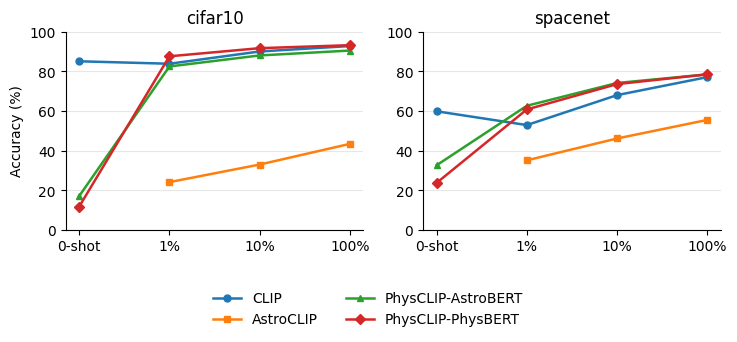

In [ ]:
# (8) Image classification — paper-style shot curves (4 baselines, 2 datasets)
# Goals:
#   - compact multi-panel (cifar10 + spacenet)
#   - shared legend OUTSIDE plot area (no overlap)
#   - short legend labels (paper-friendly)
#   - high-DPI save + W&B log

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

in_csv = RESULTS_ROOT / "image_classification_results.csv"
if not in_csv.exists() or in_csv.stat().st_size == 0:
    raise FileNotFoundError(f"Missing results CSV: {in_csv}. Run cell (7) first.")

df = pd.read_csv(in_csv)

# Keep accuracy rows; support both schemas:
if "metric" in df.columns:
    df = df[df["metric"] == "acc"].copy()

# Normalize to acc_pct
if "acc_pct" not in df.columns:
    if "value" not in df.columns:
        raise KeyError("Expected either 'acc_pct' or 'value' in image_classification_results.csv")
    v = df["value"].astype(float)
    df["acc_pct"] = np.where(v <= 1.0, v * 100.0, v)

# Exact baselines to show
MODEL_ORDER = [
    "CLIP(OpenAI)",
    "AstroCLIP",
    "PhysCLIP(AstroBERT, ep38)",
    "PhysCLIP(PhysicBERT, ep10)",
]
df = df[df["model"].isin(MODEL_ORDER)].copy()
if df.empty:
    raise ValueError("No rows found for the 4 target baselines in image_classification_results.csv")

# Short display names (paper-friendly)
DISPLAY = {
    "CLIP(OpenAI)": "CLIP",
    "AstroCLIP": "AstroCLIP",
    "PhysCLIP(AstroBERT, ep38)": "PhysCLIP-AstroBERT",
    "PhysCLIP(PhysicBERT, ep10)": "PhysCLIP-PhysBERT",
}

SHOT_ORDER = [
    ("zero-shot", "0-shot"),
    ("linear-probe-1%", "1%"),
    ("linear-probe-10%", "10%"),
    ("linear-probe-100%", "100%"),
]

DATASET_ORDER = [d for d in ["cifar10", "spacenet"] if d in df["dataset"].unique().tolist()]
if not DATASET_ORDER:
    raise ValueError("No cifar10/spacenet rows found in results CSV.")

FIG_ROOT = RESULTS_ROOT / "figures"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

# Style: rely on matplotlib default color cycle (no manual colors)
MARKERS = ["o", "s", "^", "D"]

ncols = len(DATASET_ORDER)
fig_w = 7.2  # good for paper double-column-ish
fig_h = 3.2
fig, axes = plt.subplots(1, ncols, figsize=(fig_w, fig_h), sharey=True)
if ncols == 1:
    axes = [axes]

x = np.arange(len(SHOT_ORDER))

for ax, dataset in zip(axes, DATASET_ORDER):
    for i, model in enumerate(MODEL_ORDER):
        sub = df[(df["dataset"] == dataset) & (df["model"] == model)]
        if sub.empty:
            continue

        ys = []
        for setting, _xlab in SHOT_ORDER:
            row = sub[sub["setting"] == setting]
            ys.append(float(row.iloc[0]["acc_pct"]) if len(row) else np.nan)

        ax.plot(
            x, ys,
            marker=MARKERS[i % len(MARKERS)],
            linestyle="-",
            linewidth=1.8,
            markersize=5,
            label=DISPLAY.get(model, model),
        )

    ax.set_title(dataset)
    ax.set_xticks(x)
    ax.set_xticklabels([lab for _, lab in SHOT_ORDER])
    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.grid(True, axis="y", alpha=0.30)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Accuracy (%)")

# Ensure y-axis tick labels appear on ALL panels (sharey hides labels by default)
for ax in axes[1:]:
    ax.tick_params(axis="y", labelleft=True)

# Legend OUTSIDE, below; reserve space so it never overlaps
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=2,               # 2 columns -> 2 rows for long labels, avoids squeeze
    frameon=False,
    bbox_to_anchor=(0.5, -0.06),
)

# Reserve bottom margin for legend; keep panels compact and aligned
fig.subplots_adjust(left=0.08, right=0.99, top=0.90, bottom=0.28, wspace=0.20)

out = FIG_ROOT / "imgcls_shot_curves_4baselines.png"
fig.savefig(out, dpi=300, bbox_inches="tight", pad_inches=0.03)
print("Saved:", out)

# W&B log (if available)
try:
    wandb_log_image("imgcls/shot_curves_4baselines", str(out))
except Exception:
    pass

plt.show()


## Cross-modal retrieval benchmark (AstroFig / arXiv figure–caption pairs)

This section implements **CLIP-style cross-modal retrieval**:

- **Text → Image retrieval** (caption query, retrieve the paired figure)
- **Image → Text retrieval** (figure query, retrieve the paired caption)

Metrics:
- **Recall@K (R@1, R@5, R@10)** for both directions (standard CLIP / BiomedCLIP-style evaluation).
- **Mean cosine similarity of top-K** (optional; similar to the CosmoCLIP paper's retrieval table).

We evaluate on a **held-out split** of your Hugging Face dataset (default: `tnnanh1005/AstroFig`).

Outputs:
- `results/retrieval/retrieval_results.csv`
- Quantitative plots: grouped bars of Recall@K (Text→Image and Image→Text)
- Qualitative retrieval grids (top-4 results with similarity scores)


In [ ]:

# (8.5) Hugging Face login + make HF caches persistent on Drive (IMPORTANT for speed)
#
# Why this matters:
# - The first retrieval run may download thousands of images from the dataset repo.
# - If HF caches are on the ephemeral runtime disk, the next session will re-download everything.
# - This looks like "AstroBERT is 4× slower" when in fact the FIRST baseline just pays the download cost.
#
# Put HF caches on Drive BEFORE calling load_dataset().

import os
from pathlib import Path

if Path("/content/drive/MyDrive").exists():
    os.environ.setdefault("HF_HOME", "/content/drive/MyDrive/.hf")
    os.environ.setdefault("HF_DATASETS_CACHE", "/content/drive/MyDrive/.hf/datasets")
    os.environ.setdefault("HF_HUB_CACHE", "/content/drive/MyDrive/.hf/hub")
    os.environ.setdefault("TRANSFORMERS_CACHE", "/content/drive/MyDrive/.hf/transformers")
    print("[ok] HF caches pinned to Drive:", os.environ["HF_HOME"])
else:
    print("[warn] Drive not mounted. HF caches will be ephemeral and downloads may repeat.")

from huggingface_hub import login
login()  # paste your token when prompted (do NOT hardcode tokens in notebooks)


[ok] HF caches pinned to Drive: /content/drive/MyDrive/.hf


In [ ]:
# (9) Build VALIDATION retrieval split for AstroFig using val.jsonl
#
# Your dataset columns are only ['image', 'caption'] (no path/id column), so we CANNOT match val.jsonl by image_path.
# Instead, we match by TEXT:
#   val.jsonl["description"]  <->  dataset["caption"]
#
# This cell:
# - Downloads/reads val.jsonl (local/Drive/Hub)
# - Loads the base dataset split (Hub calls it "train" because that's the only split published)
# - Selects ONLY the validation subset by matching captions to val.jsonl descriptions (Counter-based; duplicate-safe)
# - Adds a 'description' column (used downstream as TEXT_FIELD)
# - Saves subset to Drive atomically (tmp -> rename) to survive disconnects
#
# Output:
#   ds_retrieval : datasets.Dataset (validation subset)
#   IMAGE_FIELD  : str  (typically "image")
#   TEXT_FIELD   : str  ("description")

import os, json, shutil
from pathlib import Path
from collections import Counter, defaultdict
from datasets import load_dataset, load_from_disk

# ----------------------------
# 0) Persist HF caches on Drive (recommended)
# ----------------------------
if Path("/content/drive/MyDrive").exists():
    os.environ.setdefault("HF_HOME", "/content/drive/MyDrive/.hf")
    os.environ.setdefault("HF_DATASETS_CACHE", "/content/drive/MyDrive/.hf/datasets")
    os.environ.setdefault("HF_HUB_CACHE", "/content/drive/MyDrive/.hf/hub")

HF_DATASET_REPO = os.environ.get("HF_DATASET_REPO", "tnnanh1005/AstroFig")
SEED = int(os.environ.get("SEED", "42"))

# Where to store the cached validation subset
RESULTS_ROOT = Path(os.environ.get("RESULTS_ROOT", "/content/drive/MyDrive/physclip_benchmark/results"))
CACHE_ROOT = RESULTS_ROOT / "retrieval_cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

HF_TOKEN = os.environ.get("HF_TOKEN", None)
if HF_TOKEN:
    print("[ok] HF_TOKEN available (or you are already logged in).")
else:
    print("[info] No HF token found in env. Public datasets are OK; gated datasets require login/token.")

def _load_dataset_compat(repo: str, **kwargs):
    """
    Compatibility wrapper for different `datasets` versions:
    - tries without token first (works for public or if you already logged in)
    - falls back to token= or use_auth_token=
    """
    tok = kwargs.pop("token", None) or HF_TOKEN
    # try plain
    try:
        return load_dataset(repo, **kwargs)
    except TypeError:
        pass
    except Exception:
        # if it fails due to gating, we will try with token next
        pass

    # try token=
    if tok:
        try:
            return load_dataset(repo, token=tok, **kwargs)
        except TypeError:
            pass

    # try use_auth_token=
    if tok and ("use_auth_token" not in kwargs):
        kwargs["use_auth_token"] = tok
    return load_dataset(repo, **kwargs)

def _is_valid_saved_dataset(p: Path) -> bool:
    return p.exists() and (p / "dataset_info.json").exists() and (p / "state.json").exists()

def _norm_text(s: str) -> str:
    s = (s or "").strip().lower()
    s = " ".join(s.split())
    return s

# ----------------------------
# 1) Locate val.jsonl (local / Drive / Hub)
# ----------------------------
VAL_CANDIDATES = [
    Path("/content/val.jsonl"),
    Path("./val.jsonl"),
    Path("/content/drive/MyDrive/val.jsonl"),
]

VAL_PATH = None
for p in VAL_CANDIDATES:
    if p.exists():
        VAL_PATH = p
        break

download_errors = []
if VAL_PATH is None:
    try:
        from huggingface_hub import hf_hub_download
        # try common locations in repo
        for fname in ["val.jsonl", "data/val.jsonl"]:
            try:
                VAL_PATH = Path(
                    hf_hub_download(
                        repo_id=HF_DATASET_REPO,
                        repo_type="dataset",
                        filename=fname,
                        token=HF_TOKEN,
                    )
                )
                print(f"[ok] Downloaded {fname} from Hub to: {VAL_PATH}")
                break
            except Exception as e:
                download_errors.append(f"hub({fname}): {repr(e)}")
                VAL_PATH = None
    except Exception as e:
        download_errors.append(f"huggingface_hub import/download: {repr(e)}")

if VAL_PATH is None:
    raise FileNotFoundError(
        "val.jsonl not found locally and could not be downloaded from the Hub.\n"
        "Fix options:\n"
        "  (A) Upload val.jsonl into Colab runtime at /content/val.jsonl\n"
        "  (B) Put it in Drive at /content/drive/MyDrive/val.jsonl\n"
        "  (C) Ensure you are authenticated if the dataset is gated (huggingface-cli login or set HF_TOKEN)\n"
        f"Download errors: {download_errors}"
    )

print(f"[ok] Found val.jsonl at: {VAL_PATH}")

# ----------------------------
# 2) Parse val.jsonl -> ordered descriptions (validation texts)
# ----------------------------
val_descs = []
with open(VAL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        desc = obj.get("description") or obj.get("caption") or obj.get("text")
        if desc is None:
            continue
        val_descs.append(str(desc))

if len(val_descs) == 0:
    raise RuntimeError("val.jsonl parsed but produced 0 descriptions. Expected key 'description' (or 'caption'/'text').")

VAL_N = len(val_descs)
print(f"[ok] val.jsonl rows (descriptions): {VAL_N}")

SUBSET_DIR = CACHE_ROOT / f"astrofig_validation_subset_seed{SEED}_n{VAL_N}"

# Fast path: if cached subset exists and valid, load it
if _is_valid_saved_dataset(SUBSET_DIR):
    print(f"[ok] Loading cached validation subset from: {SUBSET_DIR}")
    ds_retrieval = load_from_disk(str(SUBSET_DIR))
    IMAGE_FIELD = "image" if "image" in ds_retrieval.column_names else ds_retrieval.column_names[0]
    TEXT_FIELD = "description" if "description" in ds_retrieval.column_names else "caption"
    print(f"[ok] ds_retrieval: {len(ds_retrieval)} rows | IMAGE_FIELD={IMAGE_FIELD} | TEXT_FIELD={TEXT_FIELD}")
else:
    # If directory exists but is corrupt/partial, move it aside
    if SUBSET_DIR.exists() and not _is_valid_saved_dataset(SUBSET_DIR):
        corrupt = SUBSET_DIR.with_name(SUBSET_DIR.name + "_corrupt")
        try:
            if corrupt.exists():
                shutil.rmtree(corrupt)
            shutil.move(str(SUBSET_DIR), str(corrupt))
            print(f"[warn] Found invalid cached subset; moved to: {corrupt}")
        except Exception:
            shutil.rmtree(SUBSET_DIR, ignore_errors=True)
            print("[warn] Found invalid cached subset; deleted it to rebuild.")

    print(f"[info] Building one-time validation subset at: {SUBSET_DIR}")

    # ----------------------------
    # 3) Load base dataset (Hub split name is usually 'train' for your repo)
    # ----------------------------
    ds_full = _load_dataset_compat(HF_DATASET_REPO, split="train")

    # Determine image & caption fields
    if "image" not in ds_full.column_names:
        raise RuntimeError(f"Expected an 'image' column in dataset, found: {ds_full.column_names}")
    if "caption" not in ds_full.column_names:
        raise RuntimeError(f"Expected a 'caption' column in dataset, found: {ds_full.column_names}")

    IMAGE_FIELD = "image"
    CAPTION_FIELD = "caption"

    # Build pools for duplicate-safe matching + preserve val order
    pools = defaultdict(list)  # norm_text -> list[(pos, desc)]
    for pos, desc in enumerate(val_descs):
        pools[_norm_text(desc)].append((pos, desc))

    need = Counter({k: len(v) for k, v in pools.items()})
    remaining = sum(need.values())

    # Scan captions only (remove image column to avoid loading image data into RAM)
    ds_caps = ds_full.remove_columns([c for c in ds_full.column_names if c != CAPTION_FIELD])
    n_total = len(ds_caps)

    indices = []
    matched_descs = []
    matched_pos = []

    scan_bs = 10000  # smaller chunk to reduce peak RAM
    for start in range(0, n_total, scan_bs):
        end = min(start + scan_bs, n_total)
        caps = ds_caps[start:end][CAPTION_FIELD]
        for j, cap in enumerate(caps):
            key = _norm_text(str(cap))
            if need.get(key, 0) > 0:
                pos, desc = pools[key].pop(0)
                need[key] -= 1
                remaining -= 1

                indices.append(start + j)
                matched_descs.append(desc)
                matched_pos.append(pos)

                if remaining == 0:
                    break
        if remaining == 0:
            break
        if start == 0 or (start // scan_bs) % 5 == 0:
            print(f"[scan] {end}/{n_total} rows scanned; matched {len(indices)}/{VAL_N}")

    if len(indices) == 0:
        raise RuntimeError(
            "Matched 0 rows between dataset captions and val.jsonl descriptions. "
            "This means val.jsonl['description'] does not match dataset['caption'] text."
        )

    if len(indices) < VAL_N:
        print(f"[warn] Only matched {len(indices)}/{VAL_N} validation items. "
              "Proceeding with the matched subset (metrics will use this smaller set).")

    # Reorder to follow val.jsonl order
    order = sorted(range(len(indices)), key=lambda k: matched_pos[k])
    indices = [indices[k] for k in order]
    matched_descs = [matched_descs[k] for k in order]

    # Build subset and attach 'description' used downstream
    ds_retrieval = ds_full.select(indices)
    ds_retrieval = ds_retrieval.add_column("description", matched_descs)

    TEXT_FIELD = "description"

    # Save atomically to avoid partial folder on disconnect
    tmp_dir = SUBSET_DIR.with_name(SUBSET_DIR.name + "_tmp")
    if tmp_dir.exists():
        shutil.rmtree(tmp_dir, ignore_errors=True)
    ds_retrieval.save_to_disk(str(tmp_dir))
    if SUBSET_DIR.exists():
        shutil.rmtree(SUBSET_DIR, ignore_errors=True)
    shutil.move(str(tmp_dir), str(SUBSET_DIR))
    print(f"[ok] Saved validation subset to: {SUBSET_DIR}")

    print(f"[ok] ds_retrieval: {len(ds_retrieval)} rows | IMAGE_FIELD={IMAGE_FIELD} | TEXT_FIELD={TEXT_FIELD}")

# Sanity checks
print("[ok] Columns:", ds_retrieval.column_names[:10])
print("[ok] Example caption:", str(ds_retrieval[0].get("caption", ""))[:120])
print("[ok] Example description:", str(ds_retrieval[0].get("description", ""))[:120])


[info] No HF token found in env. Public datasets are OK; gated datasets require login/token.


val.jsonl:   0%|          | 0.00/3.40M [00:00<?, ?B/s]

[ok] Downloaded val.jsonl from Hub to: /root/.cache/huggingface/hub/datasets--tnnanh1005--AstroFig/snapshots/a1640c46324f68fa3ea6e9cc1ce25a824af027a2/val.jsonl
[ok] Found val.jsonl at: /root/.cache/huggingface/hub/datasets--tnnanh1005--AstroFig/snapshots/a1640c46324f68fa3ea6e9cc1ce25a824af027a2/val.jsonl
[ok] val.jsonl rows (descriptions): 5252
[ok] Loading cached validation subset from: /content/drive/MyDrive/physclip_benchmark/results/retrieval_cache/astrofig_validation_subset_seed42_n5252
[ok] ds_retrieval: 5252 rows | IMAGE_FIELD=image | TEXT_FIELD=description
[ok] Columns: ['image', 'caption', 'description']
[ok] Example caption: An example simulation of the measurement of the maximum squared visibility as a function of projected baseline. The dash
[ok] Example description: An example simulation of the measurement of the maximum squared visibility as a function of projected baseline. The dash


In [ ]:
# (9.1) Sanity check: verify AstroBERT vs PhysicBERT are NOT producing identical embeddings
# Run this BEFORE computing full embeddings. It encodes a tiny batch and compares results.

import numpy as np
import torch

assert 'ds_retrieval' in globals(), 'Run Cell (9) first to build ds_retrieval'

def _mini_batch(ds, n=16):
    imgs = []
    txts = []
    for i in range(min(n, len(ds))):
        ex = ds[i]
        imgs.append(ex[IMAGE_FIELD])
        txts.append(ex[TEXT_FIELD])
    return imgs, txts

mini_imgs, mini_txts = _mini_batch(ds_retrieval, n=16)

def _encode_one(baseline):
    # preprocess images to a batch tensor
    px = torch.stack([baseline.preprocess(img) for img in mini_imgs], dim=0)
    zi = baseline.encode_image_batch(px).numpy().astype('float32')
    zt = baseline.encode_text_batch(list(mini_txts)).numpy().astype('float32')
    return zi, zt

zi_a, zt_a = _encode_one(physclip_astrobert)
zi_p, zt_p = _encode_one(physclip_physicbert)

print('[sanity] AstroBERT image emb mean abs:', float(np.mean(np.abs(zi_a))))
print('[sanity] PhysicBERT image emb mean abs:', float(np.mean(np.abs(zi_p))))
print('[sanity] image emb allclose?', np.allclose(zi_a, zi_p, atol=1e-6))
print('[sanity] text  emb allclose?', np.allclose(zt_a, zt_p, atol=1e-6))

# If either allclose=True, your baselines are still sharing the same underlying model/processor.


[sanity] AstroBERT image emb mean abs: 0.03552621230483055
[sanity] PhysicBERT image emb mean abs: 0.03532600402832031
[sanity] image emb allclose? False
[sanity] text  emb allclose? False


In [ ]:
# (10) Precompute retrieval embeddings + cache to Drive (TRULY resumable)
#
# Key goals:
#   1) Never lose progress after runtime disconnects
#   2) Avoid re-downloading the dataset for each baseline (use ds_retrieval subset from disk)
#   3) Support 3 baselines: CLIP(OpenAI) + PhysCLIP(AstroBERT) + PhysCLIP(PhysicBERT)

import io
import os
import json
import time
import re
import numpy as np
import torch
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from typing import Optional, Tuple, Dict, Any

RETRIEVAL_RESULTS_DIR = RESULTS_ROOT / "retrieval"
RETRIEVAL_CACHE_DIR = RESULTS_ROOT / "retrieval_cache"
RETRIEVAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RETRIEVAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _safe_slug(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z0-9]+", "_", s).strip("_")
    return s

def _to_pil(x) -> Image.Image:
    # Handles datasets.Image, PIL, dict-with-bytes, and file paths
    if isinstance(x, Image.Image):
        return x.convert("RGB")
    if isinstance(x, dict):
        if x.get("bytes") is not None:
            return Image.open(io.BytesIO(x["bytes"])).convert("RGB")
        if x.get("path") is not None:
            return Image.open(x["path"]).convert("RGB")
    if isinstance(x, str):
        try:
            return Image.open(x).convert("RGB")
        except Exception:
            pass
    try:
        return Image.fromarray(np.array(x)).convert("RGB")
    except Exception:
        raise TypeError(f"Unsupported image type: {type(x)}")

def _cache_dir_for(baseline_name: str, n: int) -> Path:
    return RETRIEVAL_CACHE_DIR / _safe_slug(baseline_name) / f"image_caption_n{n}"

def _paths(cache_dir: Path) -> Dict[str, Path]:
    return {
        "img": cache_dir / "img_emb.f16.memmap",
        "txt": cache_dir / "txt_emb.f16.memmap",
        "meta": cache_dir / "meta.json",
    }

def _load_meta(meta_path: Path) -> Dict[str, Any]:
    """Load progress metadata without expensive Path.exists() checks (Drive stat can hang).

    Returns {} if the file is missing or unreadable.
    """
    try:
        with open(meta_path, "r", encoding="utf-8") as f:
            return json.load(f)
    except FileNotFoundError:
        return {}
    except json.JSONDecodeError:
        # corrupted / partially-written file
        return {}
    except Exception as e:
        print(f"[warn] Could not read meta.json at {meta_path}: {e}")
        return {}


def _save_meta(meta_path: Path, meta: Dict[str, Any]) -> None:
    tmp = meta_path.with_suffix(".tmp")
    json.dump(meta, open(tmp, "w", encoding="utf-8"), indent=2)
    tmp.replace(meta_path)

def _infer_k_from_memmap(mm: np.memmap, eps: float = 1e-12) -> int:
    """
    Heuristic: find last index with non-trivial norm.
    Works if unfilled rows remain all-zeros (default for new memmaps).
    """
    arr = np.asarray(mm)
    n = arr.shape[0]
    step = 2048
    last = 0
    for i in range(0, n, step):
        chunk = arr[i:i+step].astype(np.float32)
        norms = np.linalg.norm(chunk, axis=1)
        filled = np.where(norms > eps)[0]
        if len(filled) > 0:
            last = i + int(filled[-1]) + 1
    return last

@torch.no_grad()
def compute_retrieval_embeddings(
    ds,
    baseline,
    image_field: str,
    text_field: str,
    n: Optional[int] = None,
    batch_size: int = 64,
    dtype: np.dtype = np.float16,
    save_every: int = 2000,
    max_retries: int = 30,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Computes aligned image/text embeddings for retrieval evaluation.
    Resumable across sessions:
      - embeddings stored as memmaps on Drive
      - progress stored in meta.json (index k)
    """
    if baseline is None or not getattr(baseline, "has_text", False) or baseline.encode_text_batch is None:
        raise RuntimeError(f"Baseline '{getattr(baseline,'name','?')}' is not retrieval-capable (needs a text encoder).")

    N = int(n) if n is not None else len(ds)
    cache_dir = _cache_dir_for(baseline.name, N)
    cache_dir.mkdir(parents=True, exist_ok=True)
    p = _paths(cache_dir)

    # Most CLIP-style baselines here produce 512-d embeddings.
    D = 512
    meta = _load_meta(p["meta"])
    created_new = False  # set True if we create new memmap files
    if "dim" in meta:
        D = int(meta["dim"])

    # Create/open memmaps (avoid Path.exists() which can be slow/hang on Drive)
    try:
        img_mm = np.memmap(p["img"], mode="r+", dtype=dtype, shape=(N, D))
    except (FileNotFoundError, OSError, ValueError):
        created_new = True
        img_mm = np.memmap(p["img"], mode="w+", dtype=dtype, shape=(N, D))
        img_mm[:] = 0
        img_mm.flush()
        img_mm = np.memmap(p["img"], mode="r+", dtype=dtype, shape=(N, D))

    try:
        txt_mm = np.memmap(p["txt"], mode="r+", dtype=dtype, shape=(N, D))
    except (FileNotFoundError, OSError, ValueError):
        created_new = True
        txt_mm = np.memmap(p["txt"], mode="w+", dtype=dtype, shape=(N, D))
        txt_mm[:] = 0
        txt_mm.flush()
        txt_mm = np.memmap(p["txt"], mode="r+", dtype=dtype, shape=(N, D))

    # Determine resume point
    # NOTE: Google Drive `stat/exists` and full-file scans can be very slow.
    # We therefore default to trusting meta.json. If meta is missing/corrupt, start from 0.
    k = int(meta.get("k", 0)) if isinstance(meta, dict) else 0
    if created_new:
        k = 0
    # Optional safety scan (off by default): set RETRIEVAL_RESUME_SCAN=1 to infer k from memmap contents.
    if (k <= 0) and (os.environ.get("RETRIEVAL_RESUME_SCAN", "0") == "1"):
        k = _infer_k_from_memmap(img_mm)
    k = max(0, min(k, N))
    meta.update({
        "baseline": baseline.name,
        "n": N,
        "dim": D,
        "dtype": str(dtype),
        "image_field": image_field,
        "text_field": text_field,
        "k": k,
        "cache_dir": str(cache_dir),
        "updated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    })
    _save_meta(p["meta"], meta)

    print(f"[run] {baseline.name}: n={N} | dim={D} | resume k={k} | cache_dir={cache_dir}")

    device = "cuda" if torch.cuda.is_available() else "cpu"

    pbar = tqdm(total=N, initial=k, desc=f"Emb {baseline.name}", dynamic_ncols=True)
    backoff = 1.0
    retries = 0

    while k < N:
        try:
            k2 = min(N, k + batch_size)
            batch = ds[k:k2]  # dict of lists

            imgs_raw = batch[image_field]
            txts = [str(t) for t in batch[text_field]]

            pil_imgs = [_to_pil(x) for x in imgs_raw]
            img_t = torch.stack([baseline.preprocess(im) for im in pil_imgs]).to(device)

            z_img = baseline.encode_image_batch(img_t)   # expected CPU tensor (B,D) normalized
            z_txt = baseline.encode_text_batch(txts)     # expected CPU tensor (B,D) normalized

            z_img = z_img.detach().cpu().numpy().astype(dtype, copy=False)
            z_txt = z_txt.detach().cpu().numpy().astype(dtype, copy=False)

            img_mm[k:k2] = z_img
            txt_mm[k:k2] = z_txt

            k = k2
            pbar.update(len(z_img))

            if (k % save_every) == 0 or k == N:
                # Flush to disk only at checkpoints; flushing every batch is very slow on Drive.
                img_mm.flush()
                txt_mm.flush()
                meta["k"] = k
                meta["updated_at"] = time.strftime("%Y-%m-%d %H:%M:%S")
                _save_meta(p["meta"], meta)

            retries = 0
            backoff = 1.0

        except Exception as e:
            retries += 1
            msg = f"{type(e).__name__}: {e}"
            print(f"[warn] {baseline.name}: error at k={k}/{N} -> {msg}")

            # Best-effort progress save
            try:
                meta["k"] = k
                meta["updated_at"] = time.strftime("%Y-%m-%d %H:%M:%S")
                _save_meta(p["meta"], meta)
            except Exception:
                pass

            if retries > max_retries:
                raise RuntimeError(f"Too many retries ({max_retries}). Last error: {msg}") from e

            sleep_s = min(backoff, 60.0)
            print(f"[warn] retrying in {sleep_s:.1f}s (will resume from k={k}) ...")
            time.sleep(sleep_s)
            backoff = min(backoff * 1.5, 60.0)
            continue

    # Final checkpoint flush
    try:
        img_mm.flush(); txt_mm.flush()
    except Exception:
        pass
    pbar.close()
    meta["k"] = k
    meta["updated_at"] = time.strftime("%Y-%m-%d %H:%M:%S")
    _save_meta(p["meta"], meta)

    return np.asarray(img_mm), np.asarray(txt_mm)

def load_cached_embeddings(
    baseline_name: str,
    n: int,
    dim: int = 512,
    dtype: np.dtype = np.float16
) -> Optional[Tuple[np.ndarray, np.ndarray]]:
    """Load cached embeddings from memmaps.

    Avoid Path.exists() on Drive (stat can hang). Instead, try opening and return None if missing.
    """
    cache_dir = _cache_dir_for(baseline_name, n)
    p = _paths(cache_dir)
    try:
        img_mm = np.memmap(p["img"], mode="r", dtype=dtype, shape=(n, dim))
        txt_mm = np.memmap(p["txt"], mode="r", dtype=dtype, shape=(n, dim))
        return np.asarray(img_mm), np.asarray(txt_mm)
    except (FileNotFoundError, OSError, ValueError) as e:
        # missing/corrupt cache
        return None


In [ ]:
# (11) Retrieval metrics: Recall@K (BiomedCLIP-style) + mean cosine@K (CosmoCLIP-style)
#
# - BiomedCLIP evaluates retrieval using Recall@K with precomputed embeddings and cosine similarity search.
# - CosmoCLIP additionally reports mean cosine similarity for top-K results.

import numpy as np

def _try_import_faiss():
    try:
        import faiss
        return faiss
    except Exception as e:
        print("[warn] FAISS not available. Exact search will use numpy (slower). Error:", e)
        return None

faiss = _try_import_faiss()

def _recall_at_k(indices: np.ndarray, ks=(1,5,10)) -> dict:
    N = indices.shape[0]
    out = {}
    gt = np.arange(N)[:, None]
    for k in ks:
        hit = (indices[:, :k] == gt).any(axis=1)
        out[k] = float(hit.mean() * 100.0)
    return out

def _mean_cos_at_k(scores: np.ndarray, ks=(1,5,10)) -> dict:
    out = {}
    for k in ks:
        out[k] = float(scores[:, :k].mean() * 100.0)
    return out

def eval_retrieval_metrics(img_emb: np.ndarray, txt_emb: np.ndarray, ks=(1,5,10)) -> dict:
    """
    Assumes aligned pairs: i-th image matches i-th caption.
    Returns:
      - i2t_R@k, t2i_R@k
      - i2t_Cos@k, t2i_Cos@k
    """
    assert img_emb.shape == txt_emb.shape
    N, D = img_emb.shape
    kmax = max(ks)

    img32 = img_emb.astype(np.float32, copy=False)
    txt32 = txt_emb.astype(np.float32, copy=False)

    # Image -> Text
    if faiss is not None:
        index_t = faiss.IndexFlatIP(D)
        index_t.add(txt32)
        sims_i2t, inds_i2t = index_t.search(img32, kmax)
    else:
        sim = img32 @ txt32.T
        inds_i2t = np.argsort(-sim, axis=1)[:, :kmax]
        sims_i2t = np.take_along_axis(sim, inds_i2t, axis=1)

    # Text -> Image
    if faiss is not None:
        index_i = faiss.IndexFlatIP(D)
        index_i.add(img32)
        sims_t2i, inds_t2i = index_i.search(txt32, kmax)
    else:
        sim = txt32 @ img32.T
        inds_t2i = np.argsort(-sim, axis=1)[:, :kmax]
        sims_t2i = np.take_along_axis(sim, inds_t2i, axis=1)

    out = {}
    rec_i2t = _recall_at_k(inds_i2t, ks)
    rec_t2i = _recall_at_k(inds_t2i, ks)
    cos_i2t = _mean_cos_at_k(sims_i2t, ks)
    cos_t2i = _mean_cos_at_k(sims_t2i, ks)

    for k in ks:
        out[f"i2t_R@{k}"] = rec_i2t[k]
        out[f"t2i_R@{k}"] = rec_t2i[k]
        out[f"i2t_Cos@{k}"] = cos_i2t[k]
        out[f"t2i_Cos@{k}"] = cos_t2i[k]

    return out


In [ ]:
# (12A) Compute / resume retrieval embeddings ONLY (no metrics / no plots)
# This cell is safe to rerun: it resumes from Drive cache and will NOT recompute completed baselines.

import numpy as np
import torch

# RETRIEVAL_BASELINES = [clip, physclip_astrobert, physclip_physicbert]
RETRIEVAL_BASELINES = [physclip_astrobert, physclip_physicbert]
# Use exactly the validation subset produced in Cell (9)
N = len(ds_retrieval)
print("[info] Retrieval eval N =", N)

# CPU is typically slower for large batches; keep a modest batch size.
BS = 64 if torch.cuda.is_available() else 32

for b in RETRIEVAL_BASELINES:
    cache_dir = _cache_dir_for(b.name, N)
    meta_path = cache_dir / "meta.json"
    meta = _load_meta(meta_path)
    k_done = int(meta.get("k", 0))
    print(f"[info] {b.name}: cache_dir={cache_dir}  done={k_done}/{N}")

    if k_done >= N:
        # Quick integrity check: can we open the memmaps?
        try:
            _ = load_cached_embeddings(b.name, N)
            print(f"[ok] {b.name}: cached embeddings ready.")
        except Exception as e:
            print(f"[warn] {b.name}: cache exists but could not be loaded ({e}). Will recompute.")
            k_done = 0

    if k_done < N:
        print(f"[run] {b.name}: computing embeddings (resume={k_done})")
        img_emb, txt_emb = compute_retrieval_embeddings(
            ds_retrieval, b,
            image_field=IMAGE_FIELD,
            text_field=TEXT_FIELD,
            n=N,
            batch_size=BS,
            save_every=2000,
            max_retries=30,
        )
        # free RAM
        del img_emb, txt_emb
        print(f"[ok] {b.name}: embeddings computed and saved to {cache_dir}")

print("[ok] All requested baselines have cached embeddings on Drive.")


[info] Retrieval eval N = 5252
[info] PhysCLIP(AstroBERT, ep60): cache_dir=/content/drive/MyDrive/physclip_benchmark/results/retrieval_cache/physclip_astrobert_ep60/image_caption_n5252  done=0/5252
[run] PhysCLIP(AstroBERT, ep60): computing embeddings (resume=0)
[run] PhysCLIP(AstroBERT, ep60): n=5252 | dim=512 | resume k=0 | cache_dir=/content/drive/MyDrive/physclip_benchmark/results/retrieval_cache/physclip_astrobert_ep60/image_caption_n5252






Emb PhysCLIP(AstroBERT, ep60):   0%|          | 0/5252 [00:00<?, ?it/s]



Emb PhysCLIP(AstroBERT, ep60):   1%|          | 32/5252 [00:59<2:41:55,  1.86s/it]



Emb PhysCLIP(AstroBERT, ep60):   1%|          | 64/5252 [02:07<2:53:59,  2.01s/it]



Emb PhysCLIP(AstroBERT, ep60):   2%|▏         | 96/5252 [02:48<2:24:55,  1.69s/it]



Emb PhysCLIP(AstroBERT, ep60):   2%|▏         | 128/5252 [03:33<2:14:33,  1.58s/it]



Emb PhysCLIP(AstroBERT, ep60):   3%|▎         | 160/5252 [04:09<1:59:21,  1.41s/it]



Emb PhysCLIP(AstroBERT, ep60):   4%|▎         | 192/5252 [04:46<1:51:48,  1.33s/it]



Emb PhysCLIP(AstroBERT, ep60):   4%|▍         | 224/5252 [05:19<1:42:54,  1.23s/it]



Emb PhysCLIP(AstroBERT, ep60):   5%|▍         | 256/5252 [06:10<1:51:33,  1.34s/it]



Emb PhysCLIP(AstroBERT, ep60):   5%|▌         | 288/5252 [06:43<1:42:51,  1.24s/it]



Emb PhysCLIP(AstroBERT, ep60):   6%|▌         | 320/5252 [07:28<1:47:02,  1.30s/it]



Emb PhysCLIP(AstroBERT, ep60):   7%|▋         | 352/52

[ok] PhysCLIP(AstroBERT, ep60): embeddings computed and saved to /content/drive/MyDrive/physclip_benchmark/results/retrieval_cache/physclip_astrobert_ep60/image_caption_n5252
[info] PhysCLIP(PhysicBERT, ep60): cache_dir=/content/drive/MyDrive/physclip_benchmark/results/retrieval_cache/physclip_physicbert_ep60/image_caption_n5252  done=0/5252
[run] PhysCLIP(PhysicBERT, ep60): computing embeddings (resume=0)
[run] PhysCLIP(PhysicBERT, ep60): n=5252 | dim=512 | resume k=0 | cache_dir=/content/drive/MyDrive/physclip_benchmark/results/retrieval_cache/physclip_physicbert_ep60/image_caption_n5252






Emb PhysCLIP(PhysicBERT, ep60):   0%|          | 0/5252 [00:00<?, ?it/s]



Emb PhysCLIP(PhysicBERT, ep60):   1%|          | 32/5252 [00:55<2:32:06,  1.75s/it]



Emb PhysCLIP(PhysicBERT, ep60):   1%|          | 64/5252 [01:58<2:41:18,  1.87s/it]



Emb PhysCLIP(PhysicBERT, ep60):   2%|▏         | 96/5252 [02:43<2:22:47,  1.66s/it]



Emb PhysCLIP(PhysicBERT, ep60):   2%|▏         | 128/5252 [03:29<2:14:40,  1.58s/it]



Emb PhysCLIP(PhysicBERT, ep60):   3%|▎         | 160/5252 [04:07<2:01:41,  1.43s/it]



Emb PhysCLIP(PhysicBERT, ep60):   4%|▎         | 192/5252 [04:47<1:55:51,  1.37s/it]



Emb PhysCLIP(PhysicBERT, ep60):   4%|▍         | 224/5252 [05:25<1:49:20,  1.30s/it]



Emb PhysCLIP(PhysicBERT, ep60):   5%|▍         | 256/5252 [06:13<1:54:19,  1.37s/it]



Emb PhysCLIP(PhysicBERT, ep60):   5%|▌         | 288/5252 [06:51<1:48:18,  1.31s/it]



Emb PhysCLIP(PhysicBERT, ep60):   6%|▌         | 320/5252 [07:39<1:52:24,  1.37s/it]



Emb PhysCLIP(PhysicBERT, ep60):   7%|▋     

[ok] PhysCLIP(PhysicBERT, ep60): embeddings computed and saved to /content/drive/MyDrive/physclip_benchmark/results/retrieval_cache/physclip_physicbert_ep60/image_caption_n5252
[ok] All requested baselines have cached embeddings on Drive.


[check] CLIP(OpenAI): mean||img||=1.000  mean||txt||=1.000  nan_img=False  nan_txt=False
[check] PhysCLIP(AstroBERT, ep60): mean||img||=1.000  mean||txt||=1.000  nan_img=False  nan_txt=False
[check] PhysCLIP(PhysicBERT, ep60): mean||img||=1.000  mean||txt||=1.000  nan_img=False  nan_txt=False
[ok] Saved retrieval results to: /content/drive/MyDrive/physclip_benchmark/results/retrieval/retrieval_results.csv


,baseline,i2t_R@1,t2i_R@1,i2t_Cos@1,t2i_Cos@1,i2t_R@5,t2i_R@5,i2t_Cos@5,t2i_Cos@5,i2t_R@10,t2i_R@10,i2t_Cos@10,t2i_Cos@10
0,CLIP(OpenAI),3.141660,2.589490,32.255718,32.762379,6.740289,5.883473,31.726128,32.103378,9.006093,8.549124,31.433804,31.768925
1,"PhysCLIP(AstroBERT, ep60)",64.832445,58.625286,65.808525,66.759247,88.518660,86.043412,60.211693,61.244221,93.164509,91.127190,57.392246,58.283031
2,"PhysCLIP(PhysicBERT, ep60)",68.545316,61.367098,67.210472,68.086472,89.984768,87.947449,61.288746,62.152664,94.268850,92.288652,58.367229,59.072788


Saved: /content/drive/MyDrive/physclip_benchmark/results/retrieval/figures/retrieval_recall_bars_paperstyle.png


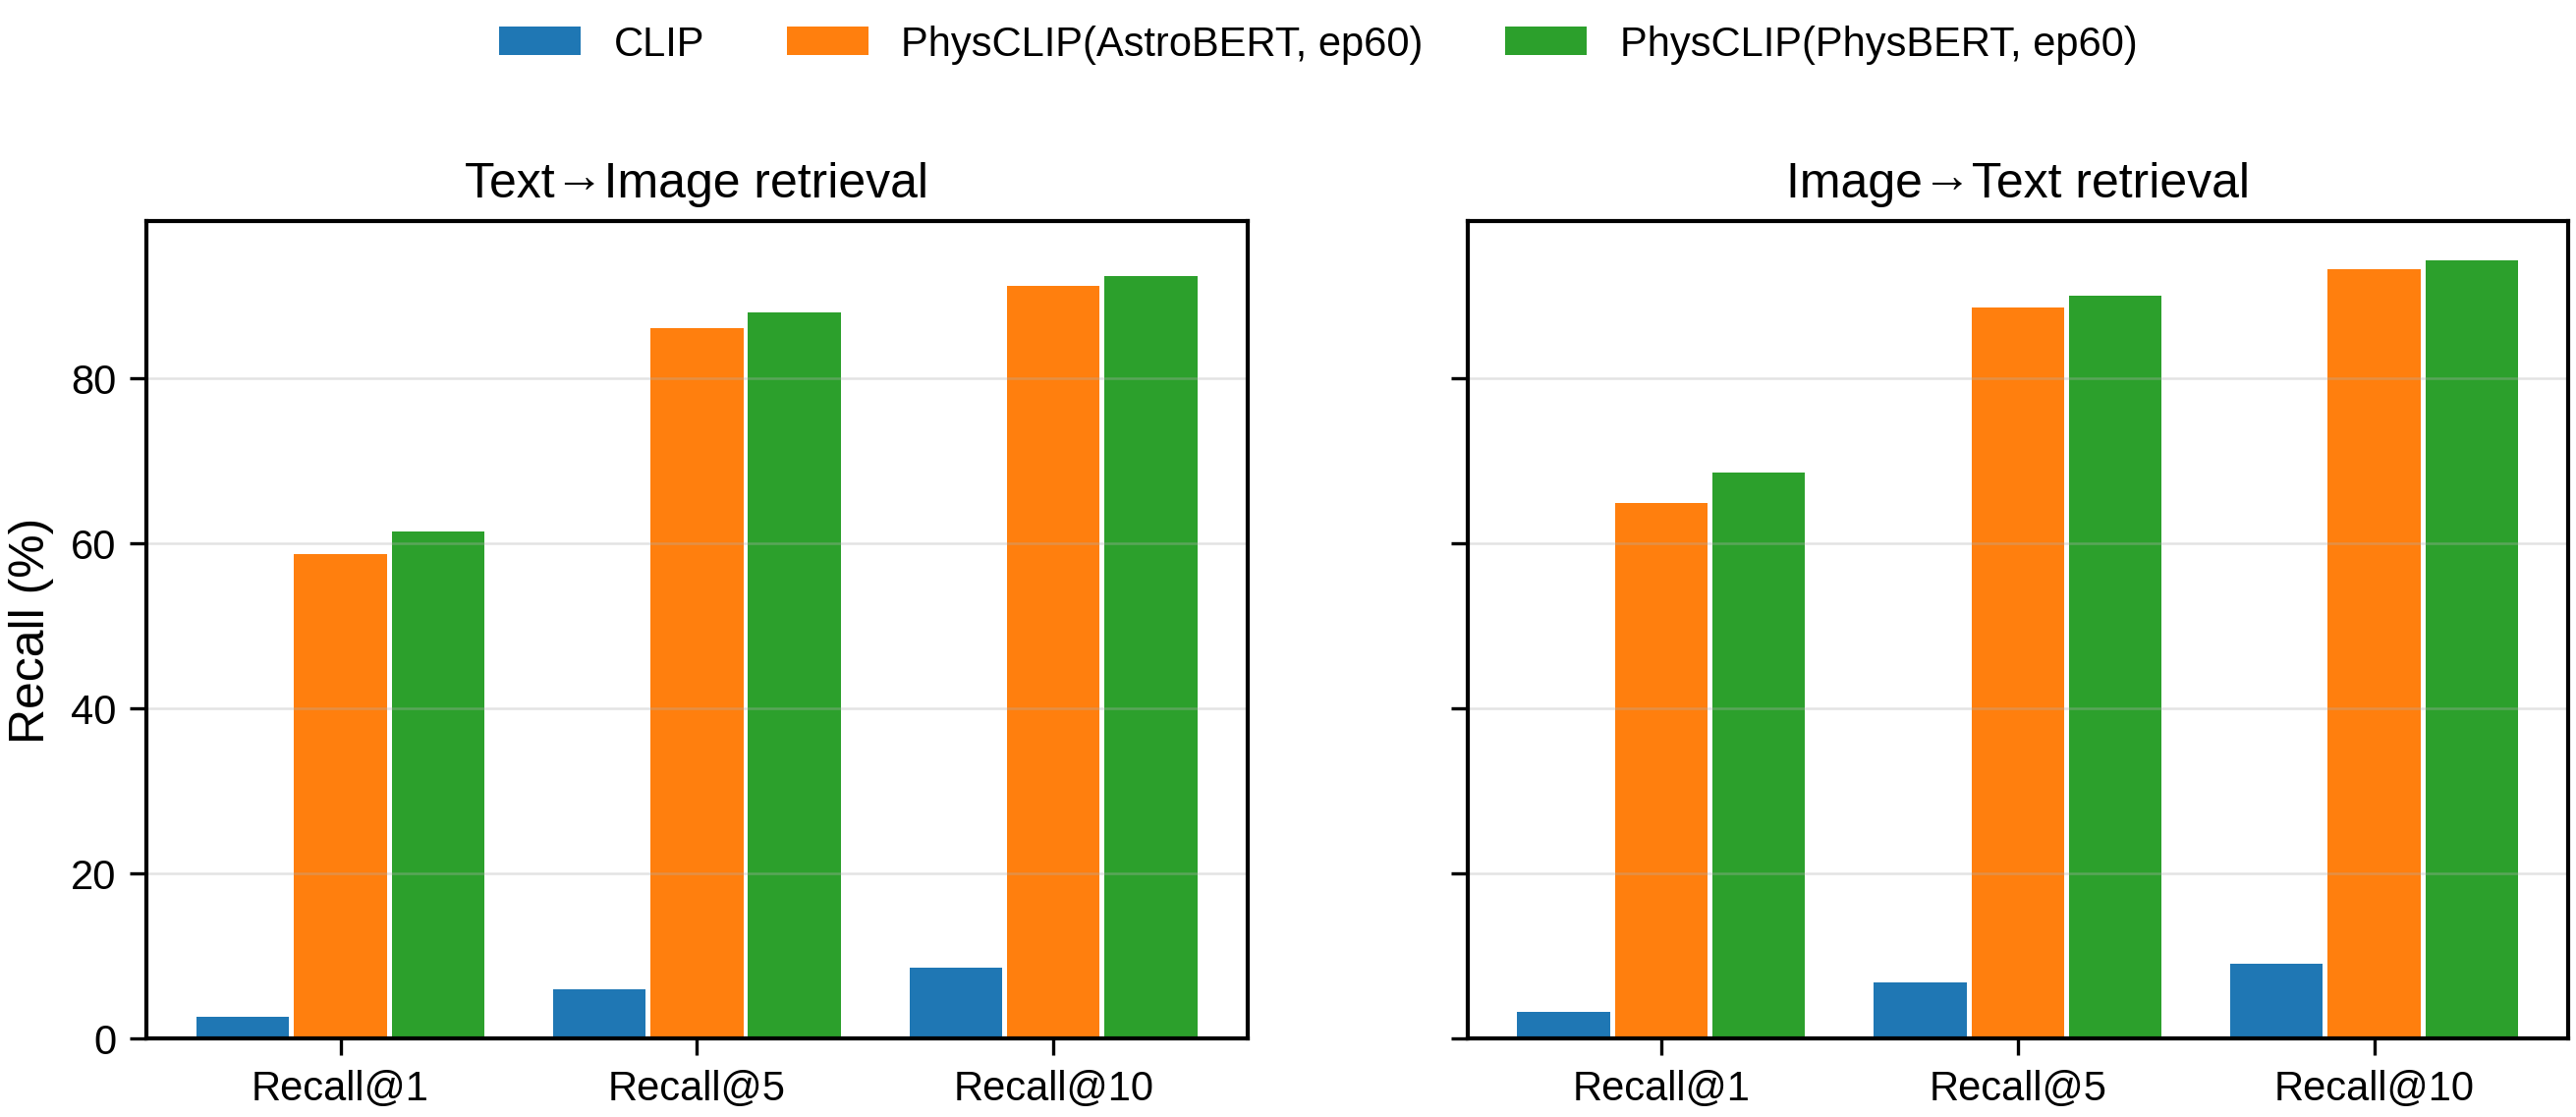

In [ ]:
# (12B) Load cached embeddings -> compute metrics + visualize (NO embedding computation)
# If this cell runs, it will never redo embeddings. If cache is missing/incomplete, it will raise with instructions.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RETRIEVAL_BASELINES = [clip, physclip_astrobert, physclip_physicbert]
N = len(ds_retrieval)

rows = []
for b in RETRIEVAL_BASELINES:
    cache_dir = _cache_dir_for(b.name, N)
    meta = _load_meta(cache_dir / "meta.json")
    k_done = int(meta.get("k", 0))
    if k_done < N:
        raise RuntimeError(
            f"Embeddings cache incomplete for {b.name}: {k_done}/{N}.\n"
            f"Run Cell (12A) first. Cache dir: {cache_dir}"
        )

    img_emb, txt_emb = load_cached_embeddings(b.name, N)

    # Basic sanity checks (helps diagnose 'one baseline is broken')
    img_norm = np.linalg.norm(img_emb.astype(np.float32), axis=1).mean()
    txt_norm = np.linalg.norm(txt_emb.astype(np.float32), axis=1).mean()
    nan_img = np.isnan(img_emb).any()
    nan_txt = np.isnan(txt_emb).any()
    print(f"[check] {b.name}: mean||img||={img_norm:.3f}  mean||txt||={txt_norm:.3f}  nan_img={nan_img}  nan_txt={nan_txt}")

    metrics = eval_retrieval_metrics(img_emb, txt_emb, ks=(1,5,10))
    rows.append({"baseline": b.name, **metrics})

    # free RAM (embeddings are memmaps; still good practice)
    del img_emb, txt_emb

df = pd.DataFrame(rows)
out_csv = RETRIEVAL_RESULTS_DIR / "retrieval_results.csv"
df.to_csv(out_csv, index=False)
print("[ok] Saved retrieval results to:", out_csv)
display(df)



# ---- Paper-style retrieval bars (BiomedCLIP-like layout) ----
# Metrics (Recall@1/5/10) on x-axis; baselines are grouped bars; two panels (T2I, I2T).

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def apply_paper_style():
    mpl.rcParams.update({
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 1.0,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "grid.linewidth": 0.6,
    })
apply_paper_style()

# Use the retrieval figure root already set in this cell (keeps outputs organized under retrieval_results/)
if "RETRIEVAL_FIG_ROOT" not in globals():
    RETRIEVAL_FIG_ROOT = RETRIEVAL_RESULTS_DIR / "figures"
    RETRIEVAL_FIG_ROOT.mkdir(parents=True, exist_ok=True)

def _save_and_log_retrieval(fig, name: str, wandb_key: str):
    out = RETRIEVAL_FIG_ROOT / name
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print("Saved:", out)
    try:
        wandb_log_image(wandb_key, str(out))
    except NameError:
        pass
    return out

plot_df = pd.DataFrame(rows).copy()
if plot_df.empty:
    raise RuntimeError("No retrieval rows to plot. Check RETRIEVAL_BASELINES / cache.")

def _short_name(s: str) -> str:
    s = str(s)
    s = s.replace("CLIP(OpenAI)", "CLIP")
    # keep PhysCLIP names readable but shorter
    s = s.replace("PhysCLIP(AstroBERT, ", "PhysCLIP(AstroBERT, ")
    s = s.replace("PhysCLIP(PhysicBERT, ", "PhysCLIP(PhysBERT, ")
    return s

plot_df["baseline_disp"] = plot_df["baseline"].map(_short_name)

# Default: plot all available baselines in the CSV order
BASELINES_SHOW = plot_df["baseline_disp"].tolist()

ks = [1, 5, 10]
metric_labels = [f"Recall@{k}" for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.6), sharey=True)

for ax, direction, title in zip(
    axes,
    ["t2i", "i2t"],
    ["Text→Image retrieval", "Image→Text retrieval"],
):
    x = np.arange(len(ks))
    nb = len(BASELINES_SHOW)
    total_width = 0.82
    width = total_width / max(nb, 1)
    offsets = (np.arange(nb) - (nb - 1) / 2.0) * width

    for i, bname in enumerate(BASELINES_SHOW):
        row = plot_df[plot_df["baseline_disp"] == bname].iloc[0]
        vals = [float(row[f"{direction}_R@{k}"]) for k in ks]
        ax.bar(x + offsets[i], vals, width=width * 0.95, label=bname)

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.35)

axes[0].set_ylabel("Recall (%)")

# Shared legend above plots (compact, paper-like)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(3, len(labels)), frameon=False, bbox_to_anchor=(0.5, 1.10))

_save_and_log_retrieval(fig, "retrieval_recall_bars_paperstyle.png", "retrieval/recall_bars_paperstyle")
plt.show()


[info] qualitative indices: [3448, 4080, 3071]
Saved: /content/drive/MyDrive/physclip_benchmark/results/retrieval/qualitative/qual_t2i_q3448.png


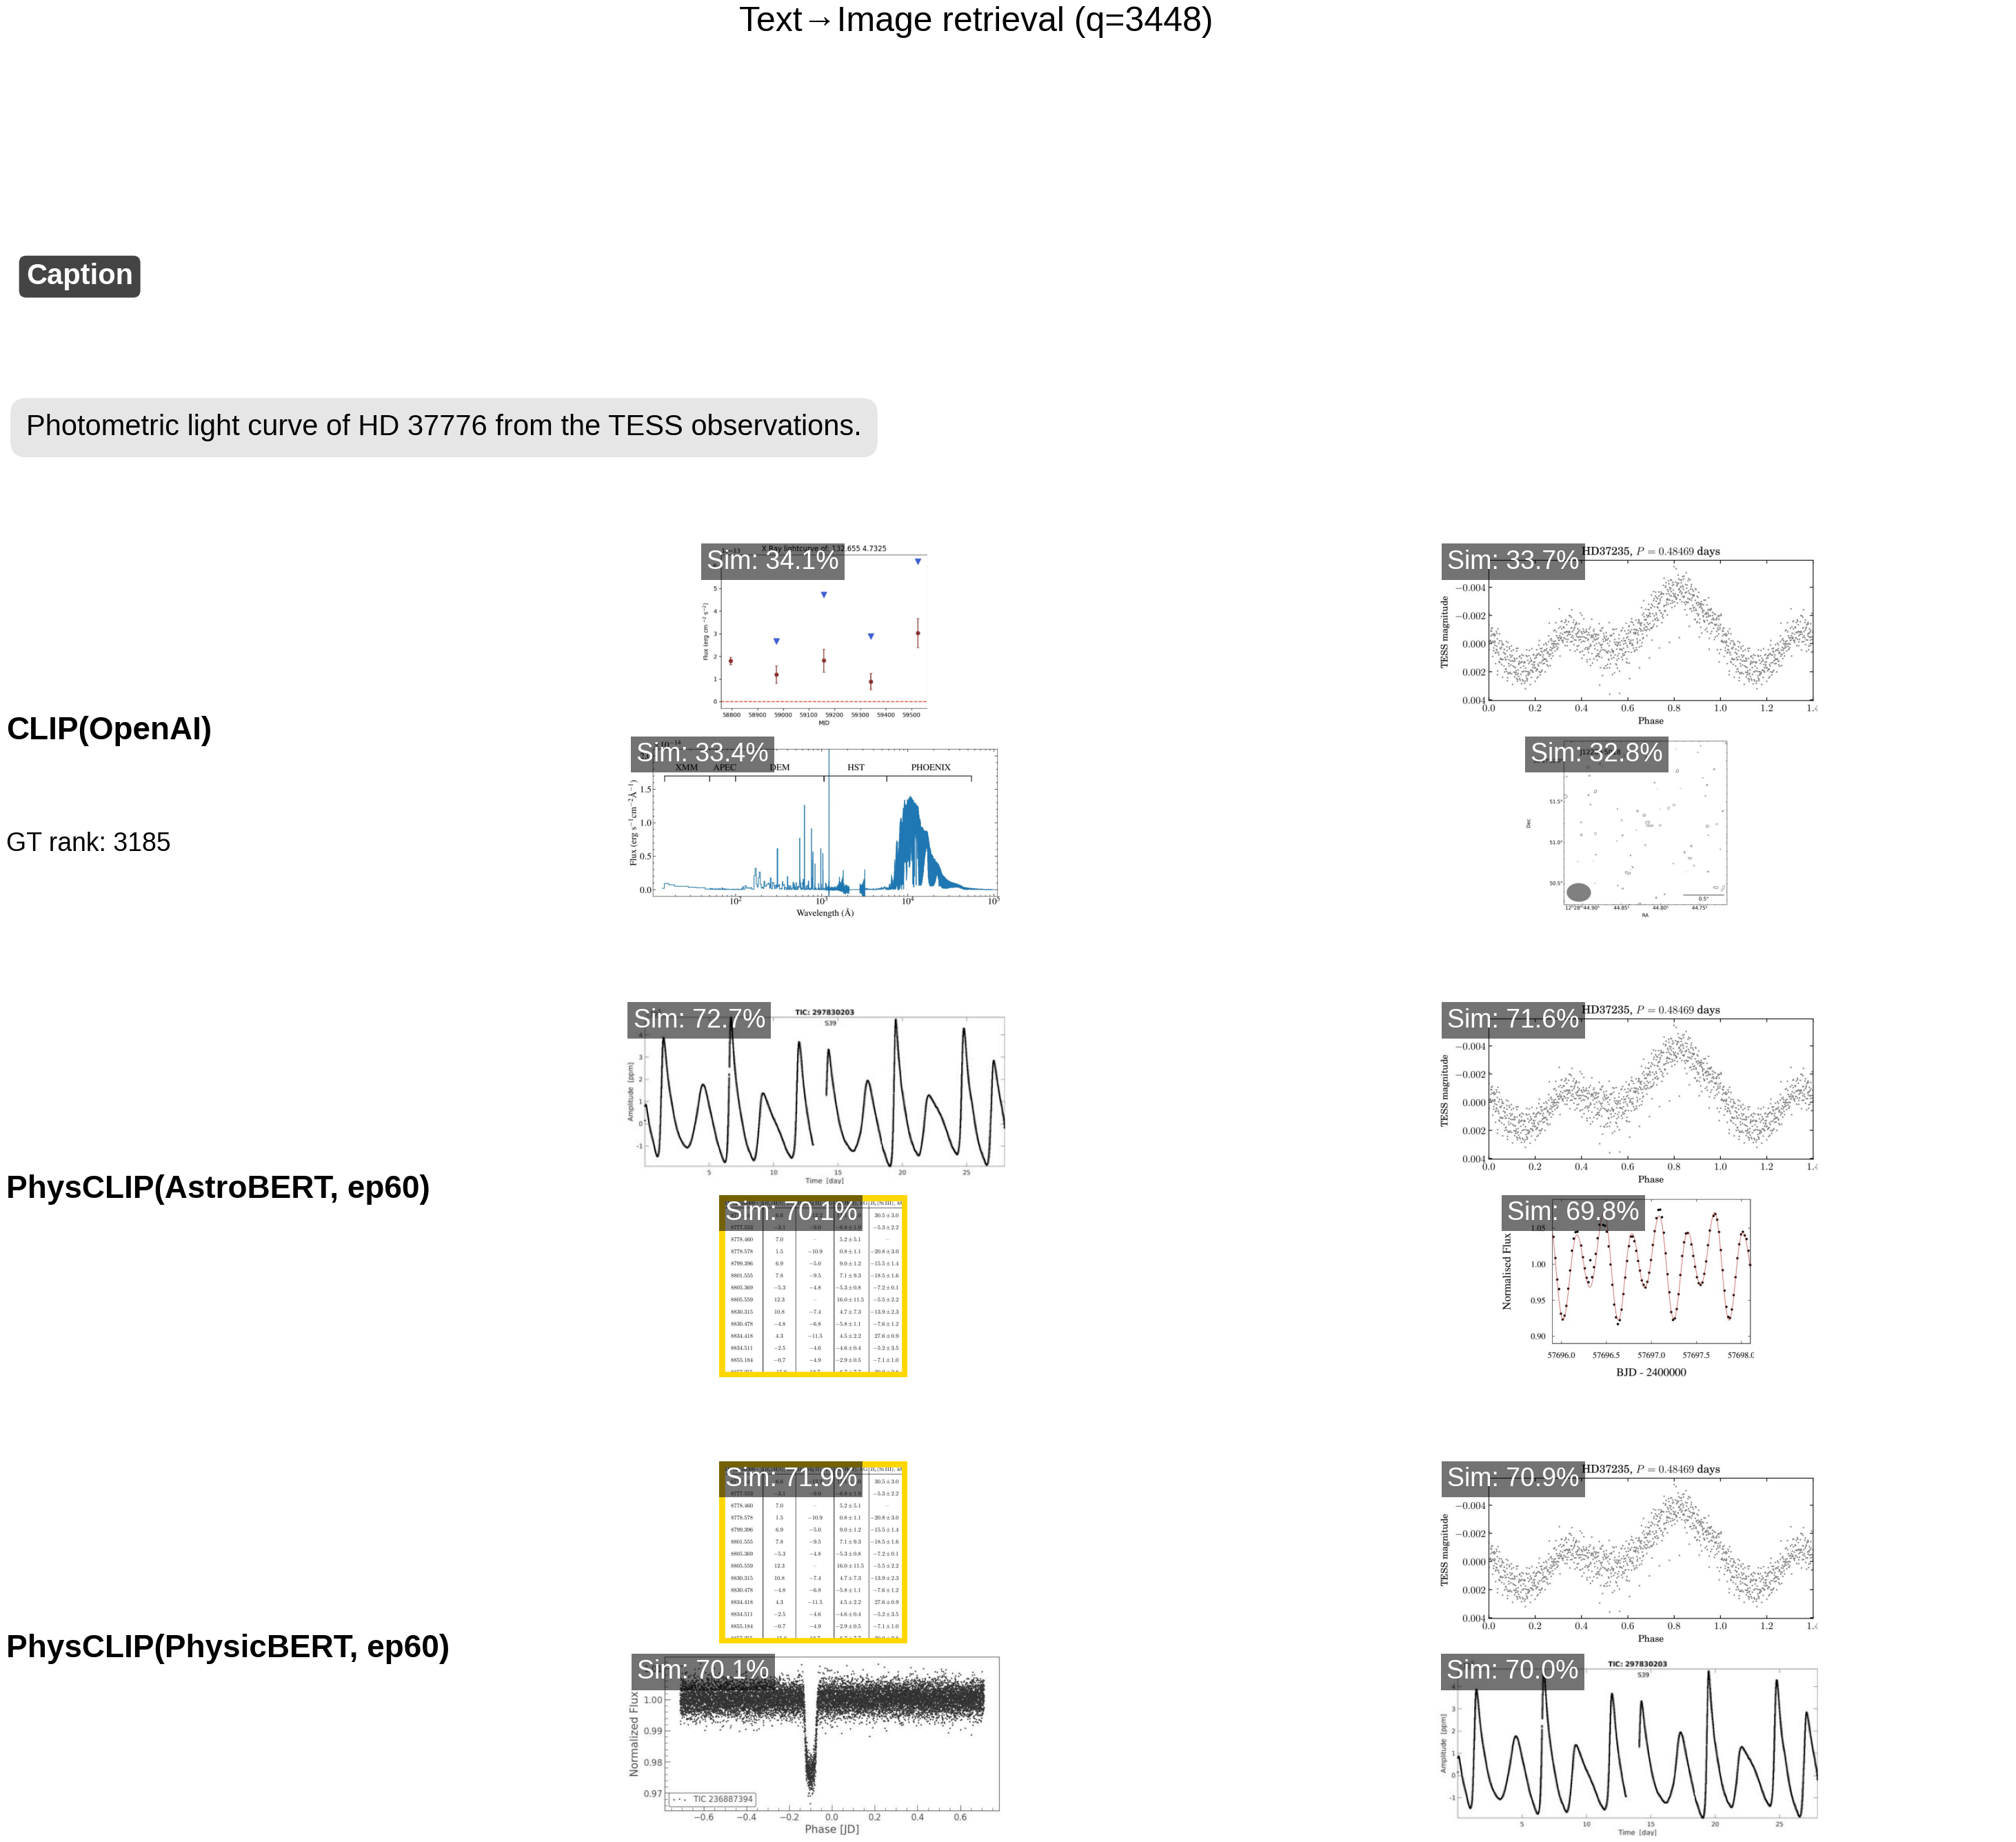

Saved: /content/drive/MyDrive/physclip_benchmark/results/retrieval/qualitative/qual_t2i_q4080.png


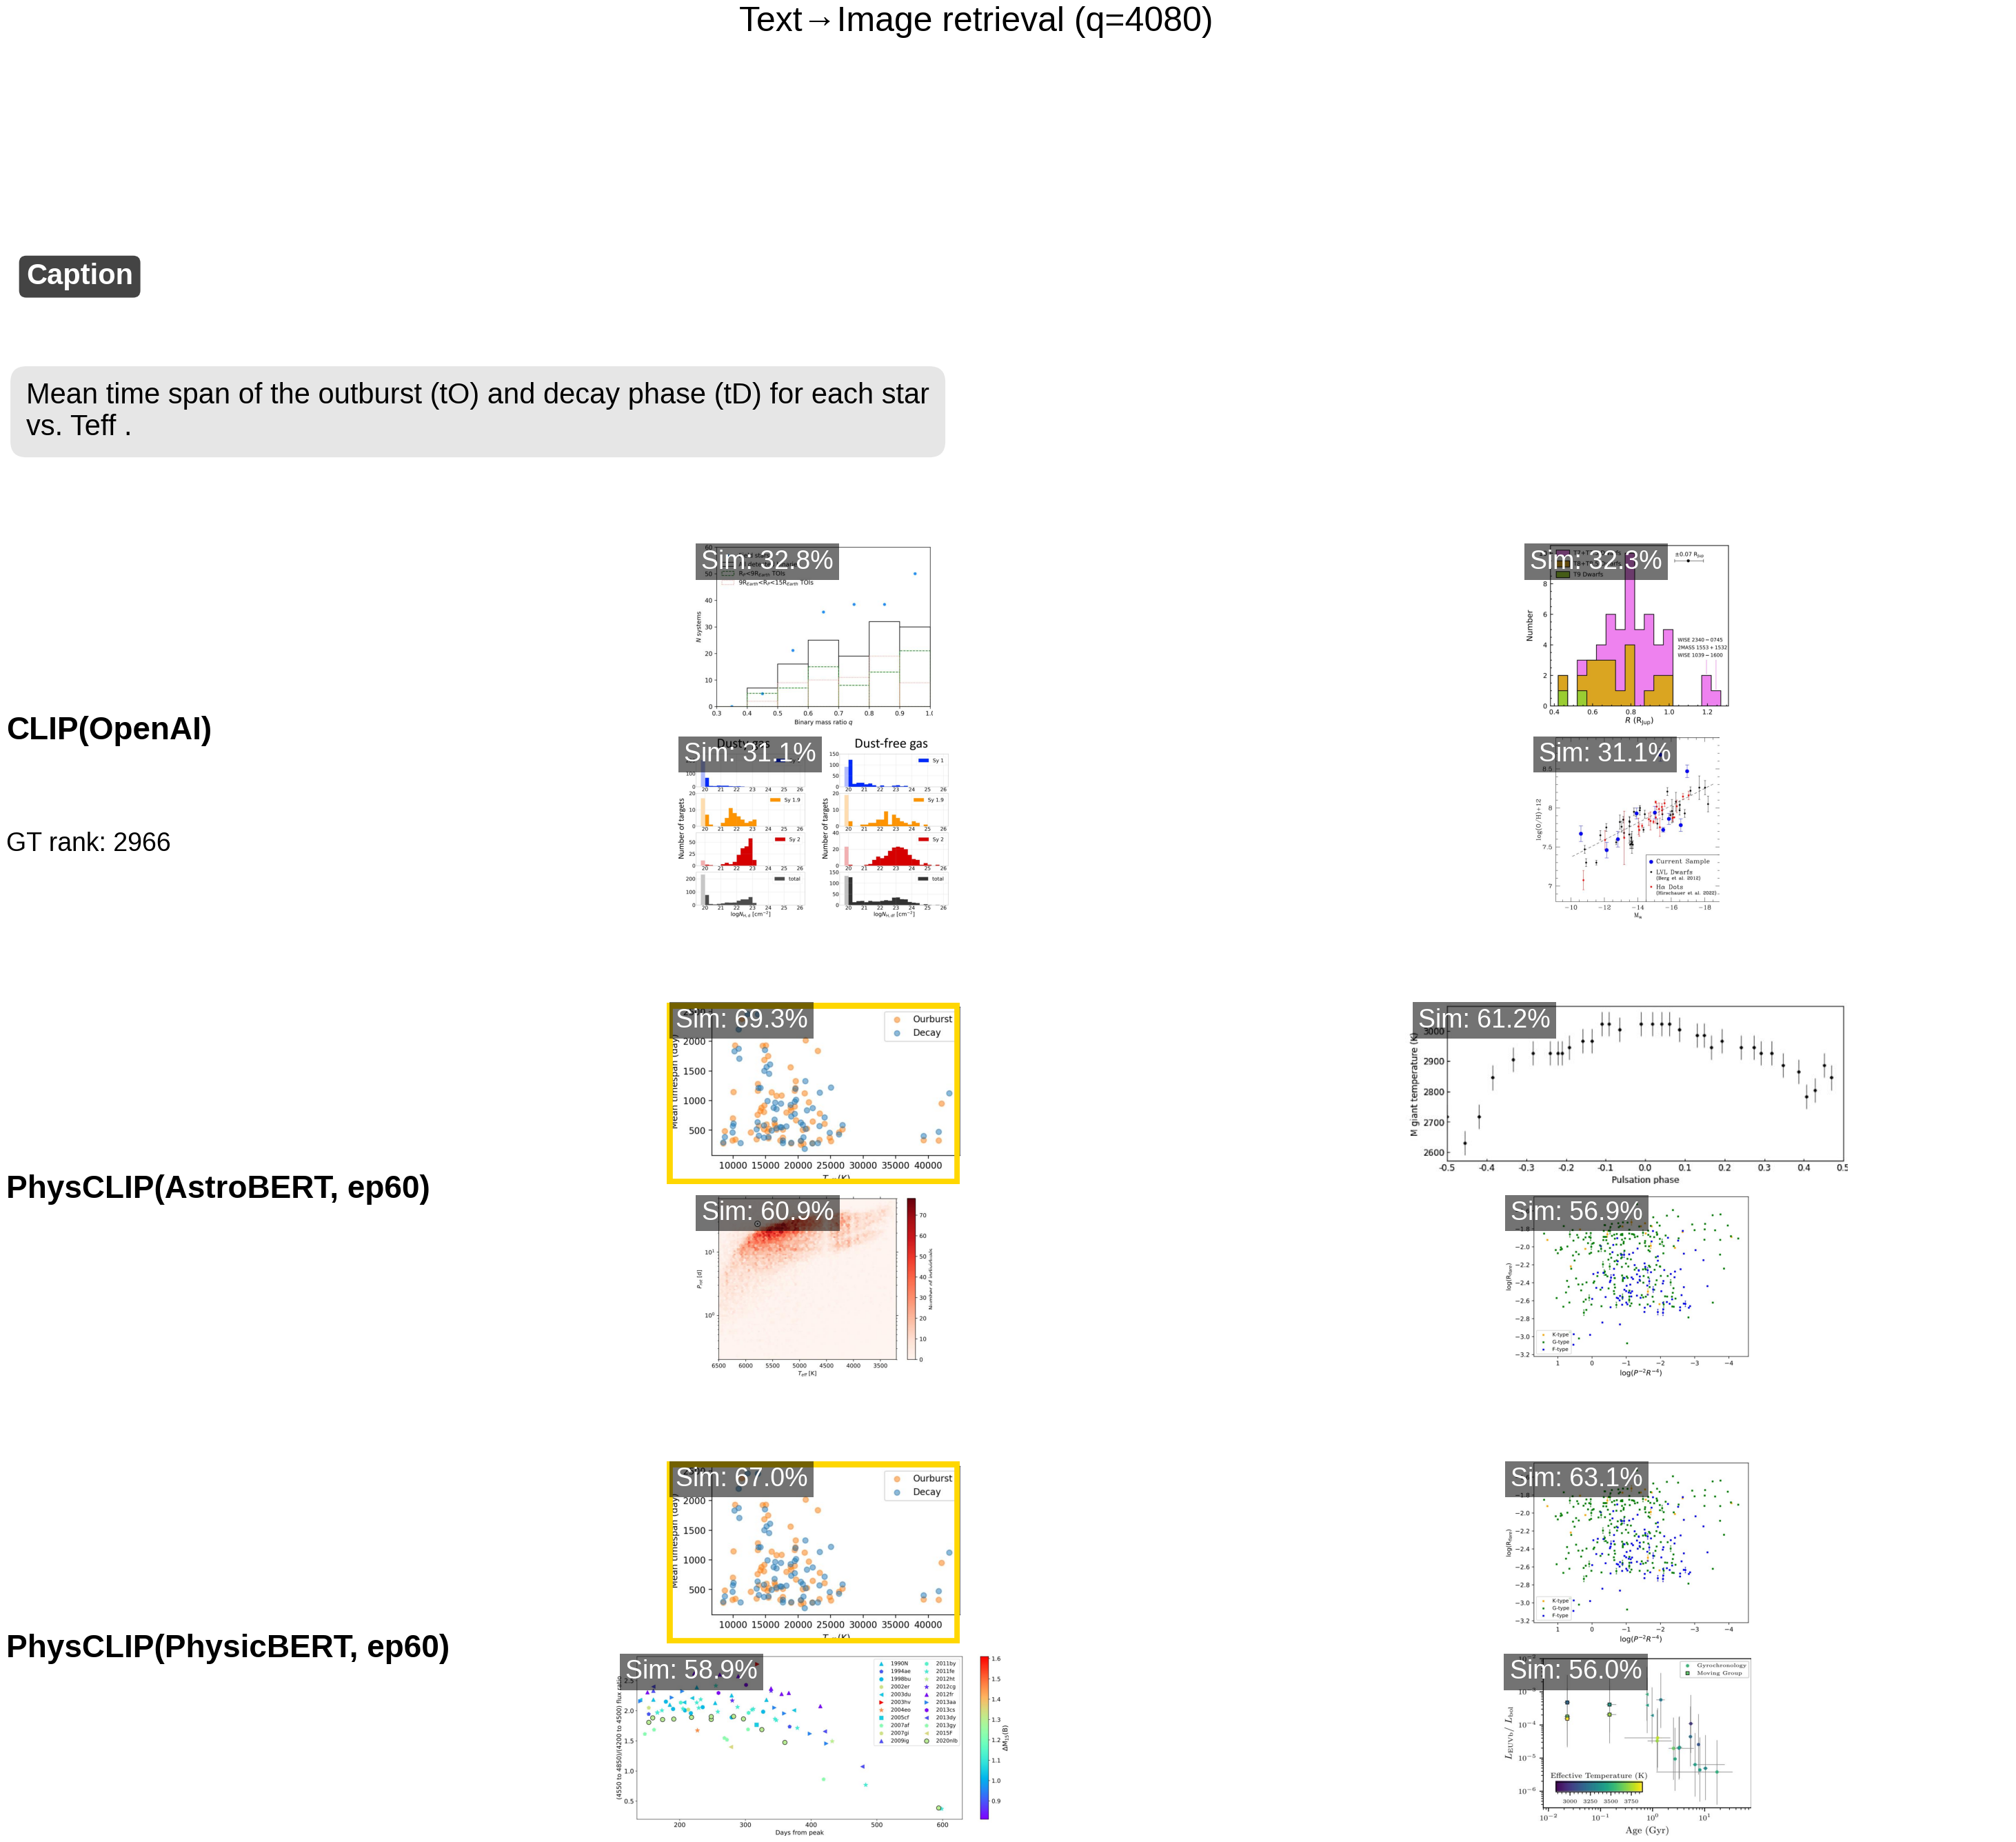

Saved: /content/drive/MyDrive/physclip_benchmark/results/retrieval/qualitative/qual_t2i_q3071.png


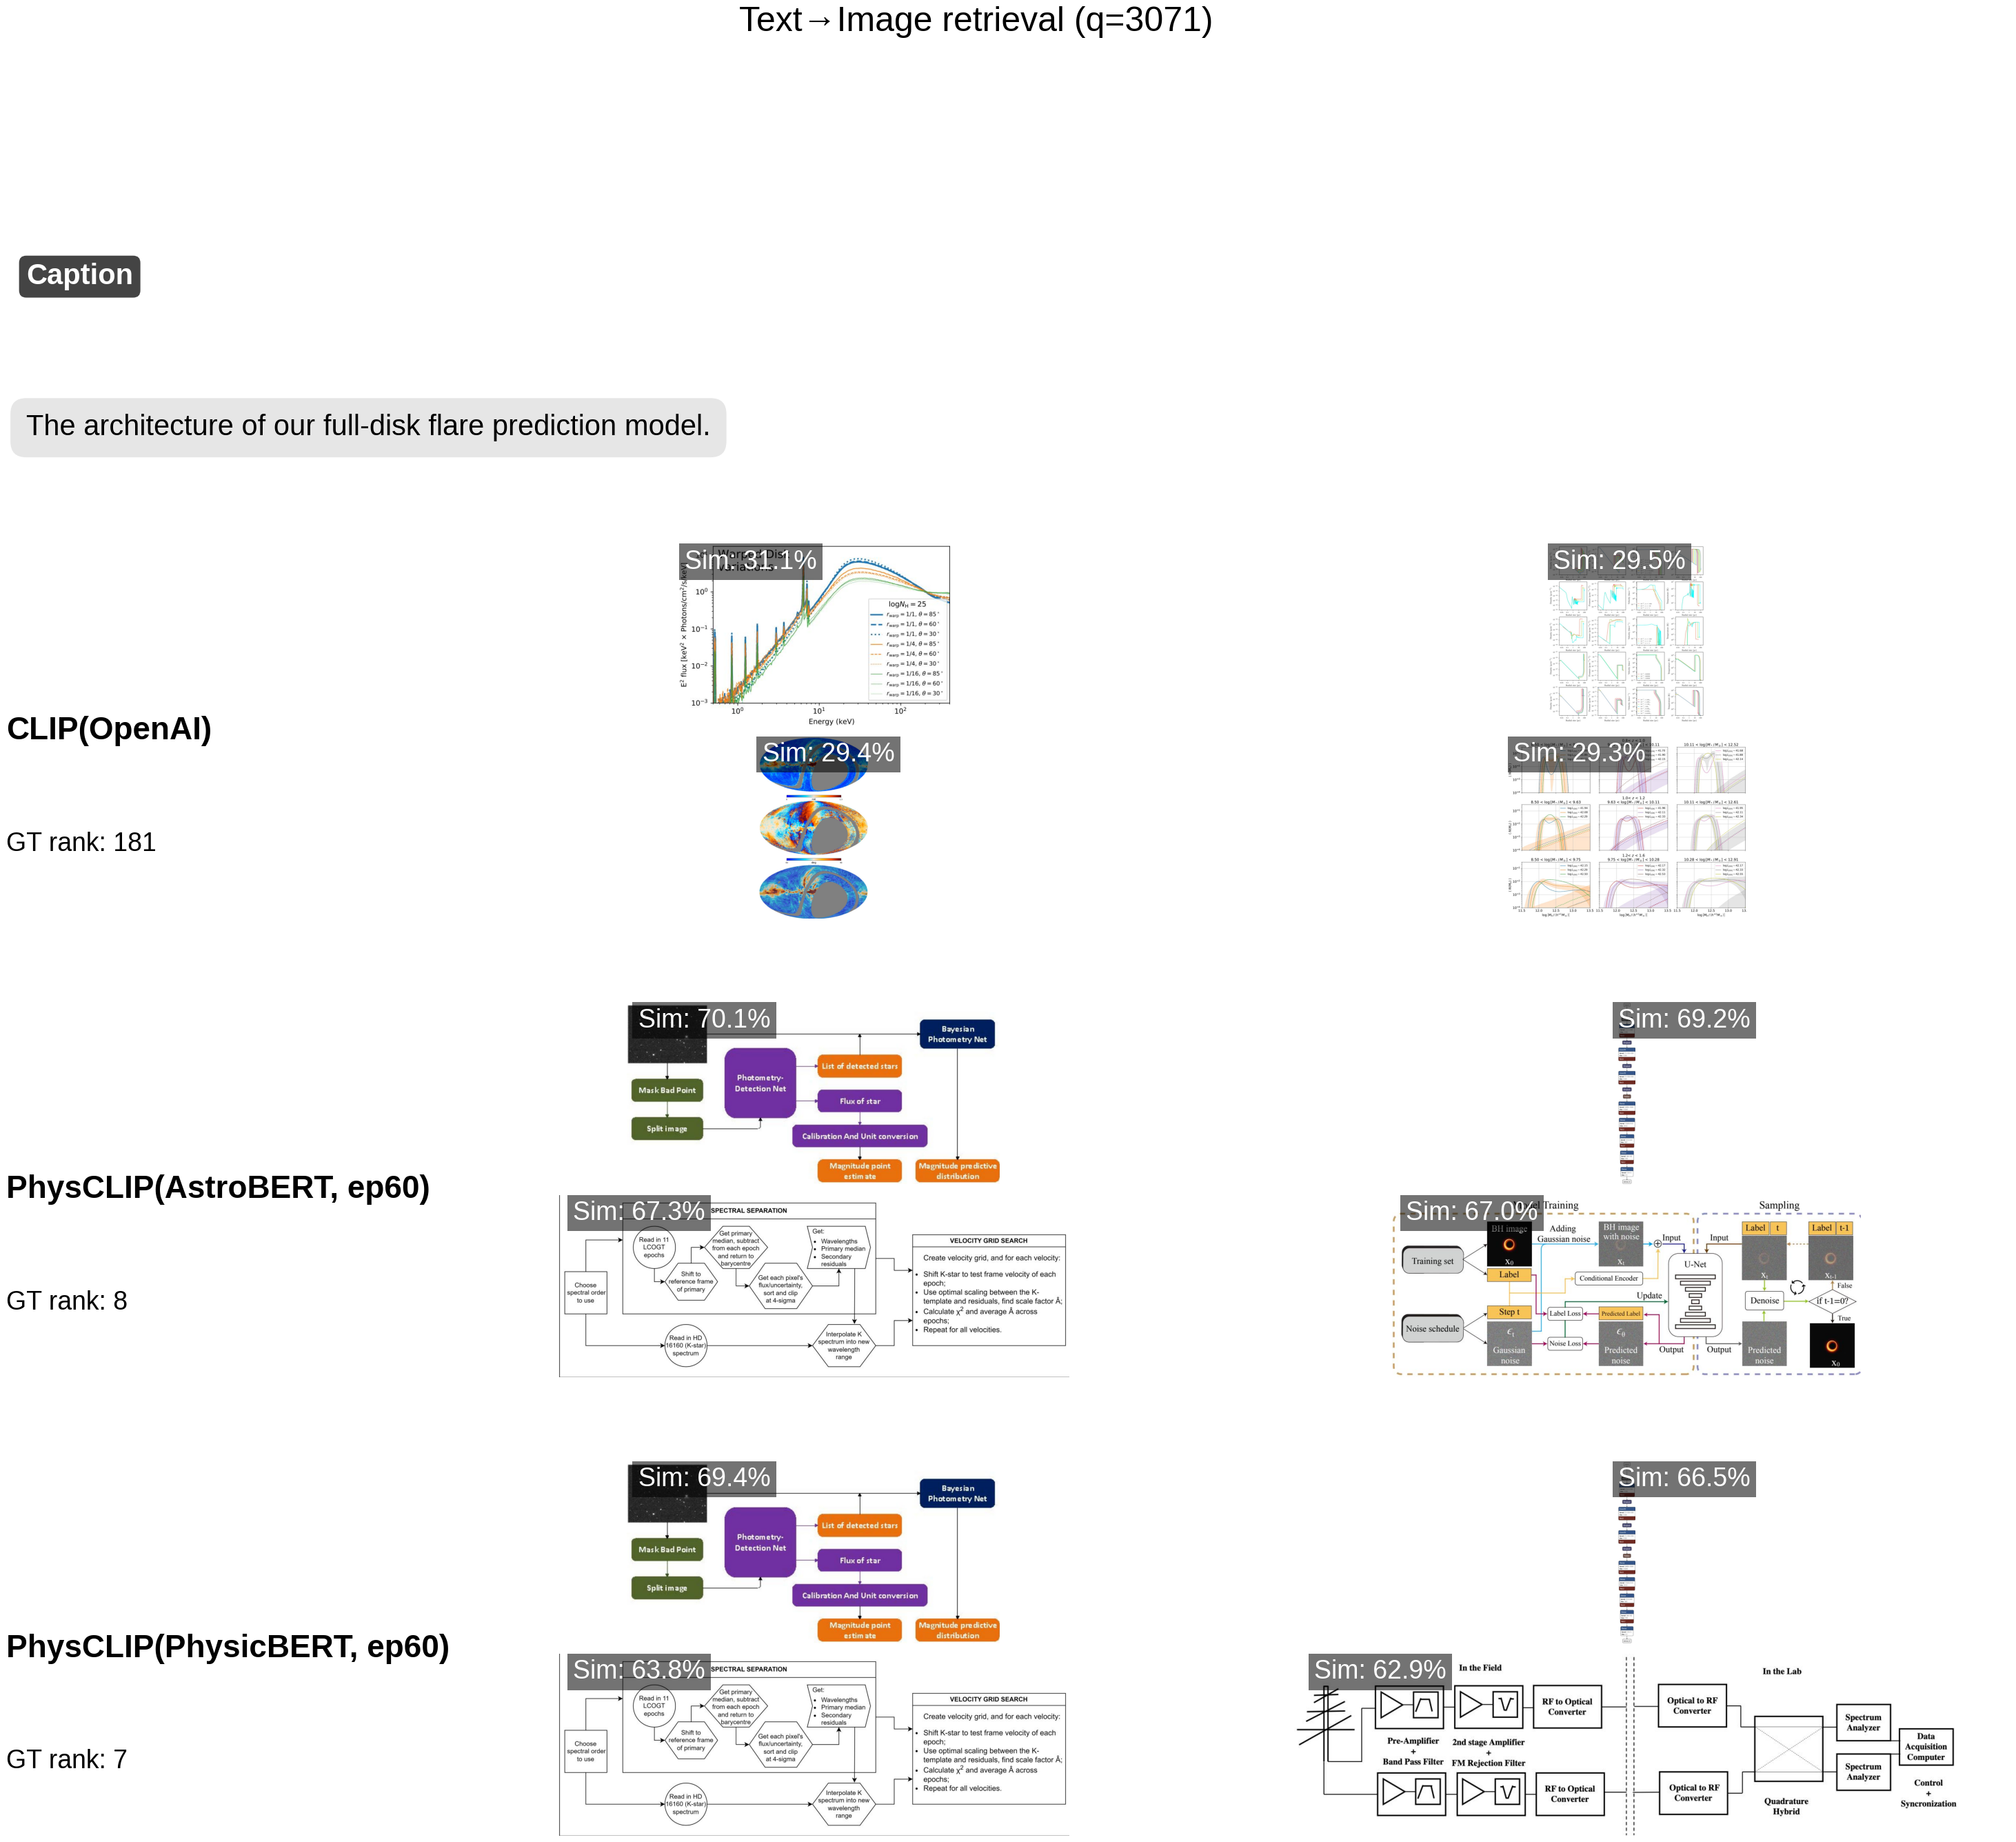

[done] qualitative figures saved under: /content/drive/MyDrive/physclip_benchmark/results/retrieval/qualitative


In [ ]:
# (12C) Qualitative retrieval visualization (BiomedCLIP Fig.2B / CosmoCLIP Fig.3 style)
# Goals:
#   - Show report-quality text->image qualitative retrieval with top-4 results
#   - Neat 2x2 grid per model (like BiomedCLIP Fig.2B)
#   - Overlay cosine similarity ("Sim") per image (like CosmoCLIP Fig.3)
#   - Highlight the ground-truth image for the caption with a yellow box

import numpy as np
import textwrap
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

assert "ds_retrieval" in globals(), "Run cell (9) to build ds_retrieval first."

# Choose which retrieval baselines to visualize (must have cached retrieval memmaps)
QUAL_BASELINES = globals().get("RETRIEVAL_BASELINES", [clip, physclip_astrobert, physclip_physicbert])

TOPK_T2I = 4
N_QUAL_EXAMPLES = 3

# Caption filtering
MAX_CAPTION_CHARS = 140      # pick only captions shorter than this for clean plots
DISPLAY_CAPTION_CHARS = 140  # truncate display to this length (wrap handles the rest)

def _shorten(text: str, max_chars: int = 140) -> str:
    text = (text or "").replace("\n", " ").strip()
    if len(text) <= max_chars:
        return text
    return text[: max_chars - 1].rstrip() + "…"

def _wrap(text: str, width: int = 70) -> str:
    return "\n".join(textwrap.wrap(text, width=width))

def _select_good_indices(ds, n: int = 3, max_chars: int = 140, seed: int = 42):
    rng = np.random.default_rng(seed)
    candidates = []
    for i in range(len(ds)):
        try:
            cap = str(ds[i][TEXT_FIELD])
        except Exception:
            continue
        cap2 = cap.replace("\n", " ").strip()
        if 20 <= len(cap2) <= max_chars:
            candidates.append(i)
    if not candidates:
        # fallback: use random indices, but we'll truncate aggressively
        candidates = list(range(min(len(ds), 200)))
    rng.shuffle(candidates)
    return candidates[:n]

def _to_pil_safe(x):
    # Robust image decoding across HF datasets / numpy / torch / file paths
    if isinstance(x, Image.Image):
        return x.convert("RGB")
    if isinstance(x, str):
        return Image.open(x).convert("RGB")
    if isinstance(x, dict) and "path" in x:
        return Image.open(x["path"]).convert("RGB")
    try:
        import torch
        if torch.is_tensor(x):
            x = x.detach().cpu().numpy()
    except Exception:
        pass
    if isinstance(x, np.ndarray):
        if x.dtype != np.uint8:
            x = np.clip(x, 0, 255).astype(np.uint8)
        if x.ndim == 2:
            return Image.fromarray(x, mode="L").convert("RGB")
        if x.ndim == 3:
            if x.shape[0] in (1, 3) and x.shape[0] < x.shape[-1]:
                # CHW -> HWC
                x = np.transpose(x, (1, 2, 0))
            return Image.fromarray(x).convert("RGB")
    # fallback to earlier helper if present
    if "_to_pil" in globals():
        return globals()["_to_pil"](x).convert("RGB")
    raise TypeError(f"Unsupported image type: {type(x)}")

def _cosine_sim_matrix(q: np.ndarray, X: np.ndarray) -> np.ndarray:
    # q: (D,), X: (N,D)
    q = q.astype(np.float32)
    X = X.astype(np.float32)
    q = q / (np.linalg.norm(q) + 1e-12)
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    return Xn @ q

def _open_memmaps_for_baseline(b, n: int):
    cache_dir = _cache_dir_for(b.name, n)
    meta = _load_meta(cache_dir / "meta.json")
    D = int(meta["dim"])
    img_path = cache_dir / "img_emb.f16.memmap"
    txt_path = cache_dir / "txt_emb.f16.memmap"
    img = np.memmap(img_path, mode="r", dtype=np.float16, shape=(n, D))
    txt = np.memmap(txt_path, mode="r", dtype=np.float16, shape=(n, D))
    return img, txt

# -------------------------
# Load all baseline embeddings once (memmaps)
# -------------------------
N = len(ds_retrieval)
_emb = {}
for b in QUAL_BASELINES:
    img, txt = _open_memmaps_for_baseline(b, N)
    _emb[b.name] = (img, txt)

qual_indices = _select_good_indices(ds_retrieval, n=N_QUAL_EXAMPLES, max_chars=MAX_CAPTION_CHARS, seed=42)
print("[info] qualitative indices:", qual_indices)

QUAL_FIG_DIR = RETRIEVAL_RESULTS_DIR / "qualitative"
QUAL_FIG_DIR.mkdir(parents=True, exist_ok=True)

def _save_and_log(fig, fname: str, wandb_key: str):
    out = QUAL_FIG_DIR / fname
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print("Saved:", out)
    try:
        wandb_log_image(wandb_key, str(out))
    except NameError:
        pass
    return out

def _plot_t2i_example(qi: int, topk: int = 4):
    query_cap = str(ds_retrieval[qi][TEXT_FIELD])
    query_disp = _wrap(_shorten(query_cap, DISPLAY_CAPTION_CHARS), width=70)

    n_models = len(QUAL_BASELINES)
    fig = plt.figure(figsize=(12.5, 2.9 * n_models + 1.35))
    gs = fig.add_gridspec(
        n_models + 1, 2,
        height_ratios=[0.60] + [1.0] * n_models,
        width_ratios=[1.15, 4.85],
        hspace=0.25, wspace=0.05
    )

    # Caption row (BiomedCLIP-like)
    ax_cap = fig.add_subplot(gs[0, :])
    ax_cap.axis("off")
    ax_cap.text(
        0.01, 0.78, "Caption",
        fontsize=10, fontweight="bold", color="white",
        bbox=dict(facecolor="#444444", edgecolor="none", boxstyle="round,pad=0.25")
    )
    ax_cap.text(
        0.01, 0.08, query_disp,
        fontsize=10, va="bottom",
        bbox=dict(facecolor="#E6E6E6", edgecolor="none", boxstyle="round,pad=0.55")
    )

    for r, b in enumerate(QUAL_BASELINES):
        ax_lbl = fig.add_subplot(gs[r + 1, 0])
        ax_lbl.axis("off")
        ax_lbl.text(0.0, 0.5, b.name, fontsize=11, fontweight="bold", va="center")

        img_emb, txt_emb = _emb[b.name]
        q_vec = np.array(txt_emb[qi])
        sims = _cosine_sim_matrix(q_vec, np.array(img_emb))
        top_idx = np.argsort(-sims)[:topk]

        # GT rank note if GT isn't in top-k
        if int(qi) not in set(map(int, top_idx)):
            rank = int(np.where(np.argsort(-sims) == qi)[0][0]) + 1
            ax_lbl.text(0.0, 0.18, f"GT rank: {rank}", fontsize=9)

        sub = gs[r + 1, 1].subgridspec(2, 2, hspace=0.06, wspace=0.06)
        for k, idx in enumerate(top_idx):
            ax = fig.add_subplot(sub[k // 2, k % 2])
            im = _to_pil_safe(ds_retrieval[int(idx)][IMAGE_FIELD])

            ax.imshow(im)
            ax.set_xticks([])
            ax.set_yticks([])
            for s in ax.spines.values():
                s.set_visible(False)

            # Similarity overlay (CosmoCLIP-like)
            ax.text(
                0.03, 0.97, f"Sim: {float(sims[idx]) * 100:.1f}%",
                transform=ax.transAxes, va="top", ha="left",
                fontsize=9, color="white",
                bbox=dict(facecolor="black", alpha=0.55, pad=2, edgecolor="none")
            )

            # Highlight GT (yellow square) if present in top-k
            if int(idx) == int(qi):
                ax.add_patch(
                    patches.Rectangle(
                        (0, 0), 1, 1,
                        transform=ax.transAxes, fill=False,
                        edgecolor="gold", linewidth=4
                    )
                )

    fig.suptitle(f"Text→Image retrieval (q={qi})", fontsize=12, y=0.99)
    return fig

# -------------------------
# Text -> Image qualitative (top-4)
# -------------------------
for qi in qual_indices:
    fig = _plot_t2i_example(qi, topk=TOPK_T2I)
    _save_and_log(fig, f"qual_t2i_q{qi}.png", f"retrieval/qual_t2i_q{qi}")
    plt.show()

print("[done] qualitative figures saved under:", QUAL_FIG_DIR)


In [ ]:
# (12C) Export top-4 retrieved images per caption (for manual redesign)
# This replaces the visualization with a file export pipeline:
#   OUT_DIR/
#     q00012_<caption_slug>/
#       caption.txt
#       ground_truth.png
#       <baseline_name>/
#         rank01_idx00012_sim34.0_GT.png
#         rank02_idx01234_sim33.1.png
#         ...
#         meta.json
#     summary.csv   (one row per saved image)

from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
from PIL import Image

assert "ds_retrieval" in globals(), "Run cell (9) to build ds_retrieval first."
assert "RETRIEVAL_RESULTS_DIR" in globals(), "RETRIEVAL_RESULTS_DIR is missing. Run retrieval setup cells first."

# -------------------------
# User knobs
# -------------------------
EXPORT_BASELINES = globals().get(
    "RETRIEVAL_BASELINES",
    [clip, physclip_astrobert, physclip_physicbert],  # fallback
)
TOPK_EXPORT = 4

# Export all captions by default. For a quick test, set MAX_QUERIES = 20.
MAX_QUERIES = None  # None = export all

# If you only want a specific subset, set QUERY_INDICES manually (e.g., [0, 10, 25]).
QUERY_INDICES = None  # None = use range(len(ds_retrieval))

# Output folder
OUT_DIR = Path(RETRIEVAL_RESULTS_DIR) / "qual_exports_topk"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Helpers
# -------------------------
def _slug(s: str, maxlen: int = 80) -> str:
    s = re.sub(r"\s+", " ", str(s)).strip()
    s = re.sub(r"[^A-Za-z0-9 _\-]+", "", s)
    s = s.strip().replace(" ", "_")
    return (s[:maxlen] if s else "caption").rstrip("_")

def _to_pil(x) -> Image.Image:
    if isinstance(x, Image.Image):
        return x.convert("RGB")
    if isinstance(x, dict):
        # HF datasets Image feature can sometimes return dict-like objects
        if x.get("path"):
            return Image.open(x["path"]).convert("RGB")
        if x.get("bytes"):
            import io
            return Image.open(io.BytesIO(x["bytes"])).convert("RGB")
    if isinstance(x, (bytes, bytearray)):
        import io
        return Image.open(io.BytesIO(x)).convert("RGB")
    if isinstance(x, np.ndarray):
        arr = x
        if arr.dtype != np.uint8:
            if arr.max() <= 1.0:
                arr = (arr * 255.0).clip(0, 255).astype(np.uint8)
            else:
                arr = arr.clip(0, 255).astype(np.uint8)
        if arr.ndim == 2:
            return Image.fromarray(arr).convert("RGB")
        if arr.ndim == 3:
            return Image.fromarray(arr).convert("RGB")
    raise TypeError(f"Unsupported image type: {type(x)}")

def _open_memmaps_for_baseline(b, n: int):
    # Prefer your existing helper(s) if present
    if "_cache_dir_for" not in globals():
        raise NameError("Missing helper _cache_dir_for. Please run the caching cell (10) first.")

    cache_dir = _cache_dir_for(b.name, n)
    meta_path = cache_dir / "meta.json"
    img_path = cache_dir / "img_emb.f16.memmap"
    txt_path = cache_dir / "txt_emb.f16.memmap"

    if not meta_path.exists() or not img_path.exists() or not txt_path.exists():
        raise FileNotFoundError(
            f"Missing cached retrieval embeddings for baseline '{b.name}'. "
            f"Expected files under: {cache_dir}.\n"
            f"Run cell (10) to build the cache first."
        )

    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)
    D = int(meta.get("D") or meta.get("dim"))

    img = np.memmap(img_path, mode="r", dtype=np.float16, shape=(n, D))
    txt = np.memmap(txt_path, mode="r", dtype=np.float16, shape=(n, D))
    return cache_dir, img, txt

def _l2_normalize_rows(M: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    denom = np.linalg.norm(M, axis=1, keepdims=True) + eps
    return M / denom

def _l2_normalize_vec(v: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    return v / (np.linalg.norm(v) + eps)

# -------------------------
# Prepare indices
# -------------------------
N = len(ds_retrieval)
if QUERY_INDICES is None:
    QUERY_INDICES = list(range(N))
if MAX_QUERIES is not None:
    QUERY_INDICES = QUERY_INDICES[: int(MAX_QUERIES)]

print(f"[info] Exporting TOPK={TOPK_EXPORT} for {len(QUERY_INDICES)} queries into: {OUT_DIR}")

# -------------------------
# Load + normalize image embeddings once per baseline (fast)
# -------------------------
baseline_store = {}
for b in EXPORT_BASELINES:
    _, img_mm, txt_mm = _open_memmaps_for_baseline(b, N)
    img_f32 = np.array(img_mm, dtype=np.float32)
    img_norm = _l2_normalize_rows(img_f32)
    baseline_store[b.name] = dict(img_norm=img_norm, txt_mm=txt_mm)
    print(f"[ok] loaded & normalized image embeddings for: {b.name}  (N={N}, D={img_norm.shape[1]})")

# -------------------------
# Export
# -------------------------
records = []

for qi in QUERY_INDICES:
    cap = str(ds_retrieval[qi][TEXT_FIELD])
    qdir = OUT_DIR / f"q{qi:05d}_{_slug(cap)}"
    qdir.mkdir(parents=True, exist_ok=True)

    # Save caption
    (qdir / "caption.txt").write_text(cap, encoding="utf-8")

    # Save GT image (paired)
    gt_img = _to_pil(ds_retrieval[qi][IMAGE_FIELD])
    gt_img.save(qdir / "ground_truth.png")

    for b in EXPORT_BASELINES:
        bdir = qdir / b.name
        bdir.mkdir(parents=True, exist_ok=True)

        img_norm = baseline_store[b.name]["img_norm"]
        txt_mm = baseline_store[b.name]["txt_mm"]

        q_vec = _l2_normalize_vec(np.array(txt_mm[qi], dtype=np.float32))
        sims = img_norm @ q_vec  # cosine similarity

        order = np.argsort(-sims)
        top_idx = order[:TOPK_EXPORT]
        gt_rank = int(np.where(order == qi)[0][0]) + 1

        # Save retrieved images
        top_meta = []
        for r, idx in enumerate(top_idx, start=1):
            idx = int(idx)
            sim = float(sims[idx])
            img = _to_pil(ds_retrieval[idx][IMAGE_FIELD])

            fname = f"rank{r:02d}_idx{idx:05d}_sim{sim*100:05.1f}"
            is_gt = (idx == int(qi))
            if is_gt:
                fname += "_GT"
            fname += ".png"

            out_path = bdir / fname
            img.save(out_path)

            rec = dict(
                query_index=int(qi),
                baseline=b.name,
                rank=int(r),
                retrieved_index=int(idx),
                sim=float(sim),
                sim_pct=float(sim * 100.0),
                is_gt=bool(is_gt),
                gt_rank=int(gt_rank),
                query_folder=str(qdir),
                image_file=str(out_path),
            )
            records.append(rec)
            top_meta.append({k: rec[k] for k in ["rank", "retrieved_index", "sim", "sim_pct", "is_gt"]})

        # Per-baseline meta.json
        meta = dict(
            query_index=int(qi),
            caption=cap,
            baseline=b.name,
            topk=int(TOPK_EXPORT),
            gt_index=int(qi),
            gt_rank=int(gt_rank),
            top=top_meta,
        )
        (bdir / "meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")

# Summary CSV
df = pd.DataFrame(records)
csv_path = OUT_DIR / "summary.csv"
df.to_csv(csv_path, index=False)

print("[done] Export complete.")
print(" - Root folder:", OUT_DIR)
print(" - Summary CSV:", csv_path)


[info] Exporting TOPK=4 for 5252 queries into: /content/drive/MyDrive/physclip_benchmark/results/retrieval/qual_exports_topk
[ok] loaded & normalized image embeddings for: CLIP(OpenAI)  (N=5252, D=512)
[ok] loaded & normalized image embeddings for: PhysCLIP(AstroBERT, ep60)  (N=5252, D=512)
[ok] loaded & normalized image embeddings for: PhysCLIP(PhysicBERT, ep60)  (N=5252, D=512)
[done] Export complete.
 - Root folder: /content/drive/MyDrive/physclip_benchmark/results/retrieval/qual_exports_topk
 - Summary CSV: /content/drive/MyDrive/physclip_benchmark/results/retrieval/qual_exports_topk/summary.csv
